# Lab 3 — Neural Networks from Scratch to PyTorch
# Group Members: Rami Abou Fakhr (ID: 2180519, email: rami.aboufakhr@studenti.unipd.it), Amir H. Q. Selakjan (ID: 2183917, email: amirhossein.qasemalipourselakjan@studenti.unipd.it), Alison Mae Worth (ID:2183914, email: alisonmae.worth@studenti.unipd.it)


**Author:** Dario Righelli, Dipartimento di Biologia (DiBio), University of Padova — dario.righelli@unipd.it

**Course:** Machine Learning and Neural Networks — Quantitative and Computational Biology

## Forward pass, backpropagation, and biological classification

This laboratory is designed for practical session.

In Lab 1 and Lab 2, we trained linear models by repeatedly applying the same logic:

```text
make predictions
compute a loss
compute gradients
update weights
```

In this lab, we extend the same idea to Neural Networks (NNs).

The key message is:

> A Neural Network (NN) is trained with the same logic as linear regression and logistic regression.  
> The difference is that the weights are organized into layers, and the error must be propagated backward through those layers.

We first build the core computations with NumPy, then we show how PyTorch automates the same ideas, and finally we apply a Neural Network (NN) to a biological classification task.

## Biological task

We use a single-cell ribonucleic acid sequencing (single-cell RNA-seq) dataset.

The classification task is:

```text
neuron vs non-neuron
```

The input matrix is:

```text
rows = cells
columns = gene expression features
```

The target vector is:

```text
label = 1  neuronal cell
label = 0  non-neuronal cell
```

## Expected input file

This notebook expects the same preprocessed file used in Lab 2:

```text
zeisel_neuron_classification.csv
```

Expected columns:

```text
cell_id
cell_type
label
gene_001__...
gene_002__...
...
```

All columns starting with `gene_` are treated as gene expression features.

## Learning goals

By the end of this lab, you should be able to:

- explain why logistic regression can be interpreted as one artificial neuron;
- implement a simple Neural Network (NN) forward pass with NumPy;
- understand the logic of backpropagation in a one-hidden-layer network;
- train a small Neural Network (NN) from scratch on a toy nonlinear problem;
- understand the minimal PyTorch workflow;
- build and train a Neural Network (NN) on biological gene expression data;
- evaluate model performance using appropriate classification metrics;
- use learning curves and regularization to reason about model complexity.

## Section 0 — Setup

We start by importing the libraries used in the notebook.

We use:

- `pathlib` to work with file paths;
- `NumPy` for matrix operations and the from-scratch Neural Network (NN);
- `pandas` for tabular biological data;
- `Matplotlib` for visualization;
- `PyTorch` for the practical Neural Network (NN) implementation.

The first part of the lab uses NumPy to make the computations explicit.  
The biological application uses PyTorch because it automatically computes gradients and makes training Neural Networks (NNs) easier in practice.

---

*Consolidated notebook — merges the **AW** and **RAF** Lab 3 submissions into a single best-of answer set. The base is AW's complete worked solutions (Sections 1–12 plus the final reflection answers). RAF's distinct per-sample gene-expression scatter has been folded into the Section 6 exercises as a supplementary view; where the two overlapped elsewhere, AW's version was kept as the more complete and correct one.*


In [1]:
# ============================================================
# Section 0 - Setup
# ============================================================
# This cell imports all libraries used in the lab and checks
# that PyTorch is available in the current Python environment.
# ============================================================

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
except ImportError as error:
    raise ImportError(
        "PyTorch is required for this lab, but it was not found in the current Python environment.\n"
        "Check the Python executable printed below and install PyTorch in that same environment."
    ) from error

np.random.seed(42)
torch.manual_seed(42)

The output above is useful for checking the computational environment.

If PyTorch is not found, the most likely reason is that the notebook kernel is not using the same Python environment in which PyTorch was installed. The printed Python executable helps diagnose that problem.

## Section 1 — Logistic regression as one artificial neuron

In Lab 2, logistic regression computed:

$$
z = Xw + b
$$

and then applied the sigmoid function:

$$
\hat{y} = \sigma(z)
$$

where:

- \(X\) is the input matrix;
- \(w\) is the vector of weights;
- \(b\) is the bias;
- \(z\) is the linear score;
- $\sigma$ is the sigmoid activation function;
- $\hat{y}$ is the predicted probability of class `1`.

This is already very close to an artificial neuron.

<p align="center">
  <img src="neuron.png" width="600">
</p>

An artificial neuron does two things:

1. it computes a weighted sum of the inputs;
2. it applies an activation function.

In our biological setting:

```text
input values = gene expression values
weights = learned importance of each gene for the neuron
bias = baseline shift
activation function = transformation applied to the linear score
```

The activation function determines how the neuron responds to the linear score. For example:

- the sigmoid function squashes the score into a value between 0 and 1;
- the Rectified Linear Unit (ReLU) keeps positive values and sets negative values to zero.

The next code cell defines the sigmoid function and plots it.

The sigmoid function is important because it converts any real-valued score into a number between 0 and 1. In binary classification, this number can be interpreted as the predicted probability of class `1`.

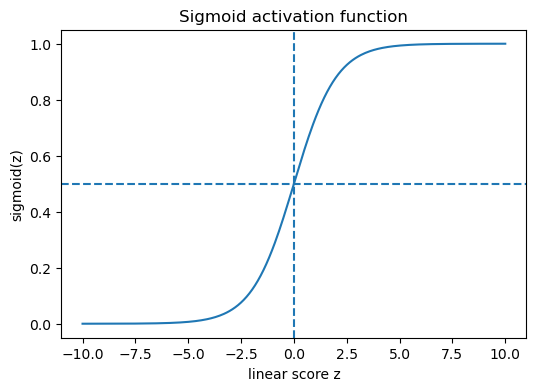

In [2]:
# ============================================================
# Section 1 - Sigmoid activation function
# ============================================================
# The sigmoid function converts real-valued scores into values
# between 0 and 1. This is why it is useful for binary
# classification probabilities.
# ============================================================

def sigmoid_numpy(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 300)
sigmoid_values = sigmoid_numpy(z_values)

plt.figure(figsize=(6, 4))
plt.plot(z_values, sigmoid_values)
plt.axhline(0.5, linestyle="--")
plt.axvline(0.0, linestyle="--")
plt.xlabel("linear score z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid activation function")
plt.show()

The plot shows that very negative scores are mapped close to 0, very positive scores are mapped close to 1, and a score of 0 is mapped to 0.5.

In a binary classifier with threshold 0.5:

```text
probability >= 0.5  → predicted class 1
probability < 0.5   → predicted class 0
```

The next code cell performs the computation of one artificial neuron on one artificial cell.

This is not yet the real biological dataset. We use three gene-like features only to make the calculation easy to inspect.

The computation is:

```text
linear score = gene_1 * weight_1 + gene_2 * weight_2 + gene_3 * weight_3 + bias
output probability = sigmoid(linear score)
```

In [3]:
# ============================================================
# Section 1 - A single artificial neuron
# ============================================================
# We manually compute the output of one neuron using:
# linear score = x @ w + b
# probability  = sigmoid(linear score)
# ============================================================

x_cell = np.array([0.8, -1.2, 0.5])
w_neuron = np.array([1.0, -0.5, 0.25])
b_neuron = -0.1

z_neuron = x_cell @ w_neuron + b_neuron
prob_neuron = sigmoid_numpy(z_neuron)

print("Input features for one cell:")
print(x_cell)

print("\nWeights:")
print(w_neuron)

print("\nBias:")
print(b_neuron)

print("\nLinear score:")
print(z_neuron)

print("\nOutput probability:")
print(prob_neuron)

Input features for one cell:
[ 0.8 -1.2  0.5]

Weights:
[ 1.   -0.5   0.25]

Bias:
-0.1

Linear score:
1.4249999999999998

Output probability:
0.8061210621761402


The symbol `@` performs a dot product between the input vector and the weight vector.

The dot product multiplies each input by its corresponding weight and then sums the results. The bias is then added to shift the score upward or downward.

This is the same basic computation used in logistic regression.

### Exercises for Section 1

These exercises connect the artificial neuron with the logistic regression model from Lab 2.

They are not meant to repeat the exact same computation. They ask you to change parts of the neuron and reason about the effect.

**Exercise 1.1**  
Change the bias while keeping the weights fixed. What happens to the output probability?

**Exercise 1.2**  
Set one weight to zero. What does this mean for the corresponding input feature?

**Exercise 1.3**  
Explain in words why logistic regression can be interpreted as a single artificial neuron.

**Exercise 1.4**  
Create two different artificial cells and compute their output probabilities using the same weights and bias.

In [4]:
# Section 1 exercises
# Written answers are in the markdown cell below.

# 1.1 - changing the bias
x_cell = np.array([0.8, -1.2, 0.5])
w_neuron = np.array([1.0, -0.5, 0.25])

for bias_try in [-2.0, -0.1, 2.0]:
    z = x_cell @ w_neuron + bias_try
    prob = sigmoid_numpy(z)
    print(f"bias={bias_try:+.2f}  z={z:+.3f}  prob={prob:.4f}")

# 1.2 - one weight set to zero
w_with_zero = np.array([1.0, 0.0, 0.25])
z = x_cell @ w_with_zero + (-0.1)
print("\n1.2 with w[1]=0, prob =", sigmoid_numpy(z))

# 1.4 - two different cells, same neuron
cell_A = np.array([0.8, -1.2, 0.5])
cell_B = np.array([-0.5, 1.0, -0.2])
w = np.array([1.0, -0.5, 0.25])
b = -0.1
print("\n1.4 cell A prob =", sigmoid_numpy(cell_A @ w + b))
print("1.4 cell B prob =", sigmoid_numpy(cell_B @ w + b))


bias=-2.00  z=-0.475  prob=0.3834
bias=-0.10  z=+1.425  prob=0.8061
bias=+2.00  z=+3.525  prob=0.9714

1.2 with w[1]=0, prob = 0.6952966693475654

1.4 cell A prob = 0.8061210621761402
1.4 cell B prob = 0.24048908305088887


**1.1** Bigger bias raises the linear score, so the sigmoid output moves toward 1; very negative bias pushes it toward 0. With weights fixed, the bias just shifts the decision threshold.

**1.2** A weight of 0 means the model ignores that feature.

**1.3** Logistic regression is `z = x·w + b` then `sigmoid(z)`. That's one neuron with a sigmoid activation.

**1.4** Same neuron, different inputs, different probabilities. The variation comes from `x`.


## Section 2 — Forward pass of a Neural Network with NumPy

A Neural Network (NN) becomes more flexible when it uses hidden layers.

A hidden layer takes the original input features and transforms them into new intermediate features. These intermediate features are called hidden activations.

For one hidden layer, the computation is:

$$
Z_1 = XW_1 + b_1
$$

$$
A_1 = f(Z_1)
$$

$$
Z_2 = A_1W_2 + b_2
$$

$$
\hat{y} = \sigma(Z_2)
$$

where:

- \(Z_1\) is the hidden linear score;
- \(X\) is the input matrix;
- \(W_1\) and \(b_1\) are the weights and bias of the hidden layer;
- \(A_1\) is the hidden activation matrix;
- \(f\) is the activation function;
- \(W_2\) and \(b_2\) are the weights and bias of the output layer;
- \(Z_2\) is the output score;
- $\hat{y}$ is the predicted probability;
- $\sigma$ is the sigmoid activation function.

<p align="center">
  <img src="NN.png" width="600">
</p>


The main point is:

> Logistic regression uses the original features directly.  
> A Neural Network (NN) learns hidden features first, then classifies using those hidden features.

The next code cell defines the Rectified Linear Unit (ReLU) activation function and its derivative.

The derivative will be needed later for backpropagation.

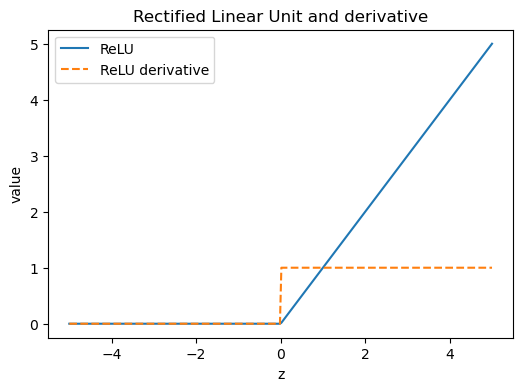

In [5]:
# ============================================================
# Section 2 - Rectified Linear Unit and derivative
# ============================================================
# ReLU keeps positive values and sets negative values to zero.
# Its derivative is 1 for positive values and 0 otherwise.
# ============================================================

def relu_numpy(z):
    return np.maximum(0, z)

def relu_derivative_numpy(z):
    return (z > 0).astype(float)

z_grid = np.linspace(-5, 5, 300)

plt.figure(figsize=(6, 4))
plt.plot(z_grid, relu_numpy(z_grid), label="ReLU")
plt.plot(z_grid, relu_derivative_numpy(z_grid), linestyle="--", label="ReLU derivative")
plt.xlabel("z")
plt.ylabel("value")
plt.title("Rectified Linear Unit and derivative")
plt.legend()
plt.show()

The plot shows that the Rectified Linear Unit (ReLU) removes negative values and keeps positive values unchanged.

The derivative is needed during backpropagation because it tells us whether the error should pass backward through a hidden unit.

The next code cell performs a complete forward pass through a tiny Neural Network (NN).

We use:

```text
2 samples
3 input features
4 hidden neurons
1 output neuron
```

The purpose is to inspect the matrix dimensions and understand how information moves from the input layer to the hidden layer and then to the output layer.

In [6]:
# ============================================================
# Section 2 - Manual forward pass with NumPy
# ============================================================
# Network: X → Z1 → A1 → Z2 → y_prob
# ============================================================

# Tiny input matrix: 2 samples x 3 features
X_tiny = np.array([
    [0.2, -1.0, 0.5],
    [1.2, 0.3, -0.7]
])

# Define network size
n_features = X_tiny.shape[1]
n_hidden = 4

# Reproducible random initialization
rng = np.random.default_rng(42)

# Hidden layer parameters
# W1: input features x hidden neurons
# b1: one bias per hidden neuron
W1 = rng.normal(loc=0.0, scale=0.2, size=(n_features, n_hidden))
b1 = np.zeros((1, n_hidden))

# Output layer parameters
# W2: hidden neurons x output neuron
# b2: one output bias
W2 = rng.normal(loc=0.0, scale=0.2, size=(n_hidden, 1))
b2 = np.zeros((1, 1))

# Hidden linear scores: 2 samples x 4 hidden neurons
Z1 = X_tiny @ W1 + b1

# Hidden activations after ReLU
A1 = relu_numpy(Z1)

# Output score: 2 samples x 1 output neuron
Z2 = A1 @ W2 + b2

# Convert output scores into probabilities
y_prob_tiny = sigmoid_numpy(Z2)

# Inspect how shapes change through the network
print("X_tiny shape:", X_tiny.shape)
print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("Z1 shape:", Z1.shape)
print("A1 shape:", A1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)
print("Z2 shape:", Z2.shape)
print("y_prob_tiny shape:", y_prob_tiny.shape)

print("\nPredicted probabilities:")
print(y_prob_tiny)

X_tiny shape: (2, 3)
W1 shape: (3, 4)
b1 shape: (1, 4)
Z1 shape: (2, 4)
A1 shape: (2, 4)
W2 shape: (4, 1)
b2 shape: (1, 1)
Z2 shape: (2, 1)
y_prob_tiny shape: (2, 1)

Predicted probabilities:
[[0.50333309]
 [0.4973066 ]]


The hidden layer transforms the original three input features into four hidden activations.

So the network creates a new representation:

```text
original features → hidden activations → output probability
```

The final output has one value per sample because this is a binary classification model with one output neuron.

### Exercises for Section 2


**Exercise 2.1**  
Change the number of hidden neurons from 4 to 2. How do the shapes of `W1`, `A1`, and `W2` change?

**Exercise 2.2**  
Replace Rectified Linear Unit (ReLU) with sigmoid in the hidden layer. Do the hidden activations look different?

**Exercise 2.3**  
Count manually the number of learnable parameters in the tiny network.

**Exercise 2.4**  
Explain why the output still has one value per sample even though the hidden layer has multiple neurons.

In [7]:
# Section 2 exercises

# 2.1 - hidden size 2 instead of 4
rng_e = np.random.default_rng(42)
W1s = rng_e.normal(0.0, 0.2, size=(X_tiny.shape[1], 2))
b1s = np.zeros((1, 2))
W2s = rng_e.normal(0.0, 0.2, size=(2, 1))
b2s = np.zeros((1, 1))

A1s = relu_numpy(X_tiny @ W1s + b1s)
y_prob_s = sigmoid_numpy(A1s @ W2s + b2s)
print("2.1 shapes -> W1:", W1s.shape, " A1:", A1s.shape, " W2:", W2s.shape)

# 2.2 - sigmoid vs ReLU in the hidden layer
Z1_again = X_tiny @ W1 + b1
print("\n2.2 ReLU hidden activations:\n", relu_numpy(Z1_again))
print("\n2.2 Sigmoid hidden activations:\n", sigmoid_numpy(Z1_again))

# 2.3 - parameter count by hand
total = 3*4 + 4 + 4*1 + 1
print("\n2.3 params = 3*4 + 4 + 4*1 + 1 =", total)


2.1 shapes -> W1: (3, 2)  A1: (2, 2)  W2: (2, 1)

2.2 ReLU hidden activations:
 [[0.40071561 0.13353214 0.09238976 0.1786503 ]
 [0.         0.         0.06466299 0.09787011]]

2.2 Sigmoid hidden activations:
 [[0.59885958 0.53333352 0.52308103 0.54454417]
 [0.48960703 0.44811228 0.51616012 0.52444801]]

2.3 params = 3*4 + 4 + 4*1 + 1 = 21


**2.1** With 2 hidden units instead of 4:
- `W1`: (3, 4) → (3, 2)
- `A1`: (2, 4) → (2, 2)
- `W2`: (4, 1) → (2, 1)

Input and output shapes don't change.

**2.2** ReLU clips negatives to 0 and leaves positives alone; sigmoid squashes everything into (0, 1). ReLU can be sparse and unbounded above, sigmoid is smooth and bounded.

**2.3** The learnable parameters are the weights and the biases. For the tiny network (3 input features, 4 hidden units, 1 output unit):
- First-layer weights: each of the 3 features connects to all 4 hidden units → 3 × 4 = 12
- Second-layer weights: each of the 4 hidden activations connects to the 1 output unit → 4 × 1 = 4
- Hidden biases: one per hidden unit → 4
- Output bias: one for the output unit → 1

Total = 12 + 4 + 4 + 1 = **21** parameters.

**2.4** Binary classification needs one probability per cell, so the output layer is `Linear(n_hidden, 1)`.


## Section 3 — Backpropagation from scratch, guided

The training loop is the same idea as in Lab 1 and Lab 2:

```text
forward pass
compute loss
compute gradients
update weights
```

The difference is that a Neural Network (NN) has multiple layers.

Therefore, the error must be propagated backward:

```text
loss → output layer → hidden layer → input weights
```

This is called backpropagation.

We will not derive all formulas in detail. Instead, we will use the formulas and focus on their meaning.

The next code cell defines Binary Cross-Entropy (BCE).

Binary Cross-Entropy (BCE) is the same loss used in logistic regression for binary classification. It is small when the model assigns high probability to the correct class and large when the model is confidently wrong.

In [8]:
# ============================================================
# Section 3 - Binary Cross-Entropy loss
# ============================================================
# BCE compares true binary labels with predicted probabilities.
# We clip probabilities to avoid log(0).
# ============================================================

def binary_cross_entropy_numpy(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)

    loss = -np.mean(
        y_true * np.log(y_prob) +
        (1 - y_true) * np.log(1 - y_prob)
    )

    return loss

The next code cell defines a complete forward pass as a reusable function.

The function returns both the predictions and a `cache`.

The cache stores intermediate quantities such as \(Z_1\), \(A_1\), and \(Z_2\), which are needed later during backpropagation.

In [9]:
# ============================================================
# Section 3 - Forward pass function
# ============================================================
# The cache stores intermediate values needed for gradients.
# ============================================================

def forward_pass_numpy(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu_numpy(Z1)
    Z2 = A1 @ W2 + b2
    y_prob = sigmoid_numpy(Z2)

    cache = {
        "X": X,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "y_prob": y_prob
    }

    return y_prob, cache

The next code cell defines the backward pass.

The most important quantity is:

```text
dZ2 = y_prob - y
```

This is the output-layer error. From there, the error is propagated backward to compute gradients for both layers.

The gradients tell us how to update each parameter to reduce the loss.

In [10]:
# ============================================================
# Section 3 - Backward pass function
# ============================================================
# Manual NumPy backpropagation for a one-hidden-layer network.
# It computes gradients for W1, b1, W2, and b2.
# ============================================================

def backward_pass_numpy(y_true, W2, cache):
    # Values saved during the forward pass
    X = cache["X"]
    Z1 = cache["Z1"]
    A1 = cache["A1"]
    y_prob = cache["y_prob"]

    # Number of samples
    n = X.shape[0]

    # Output layer error
    # For sigmoid + Binary Cross-Entropy:
    # dZ2 = predicted probability - true label
    dZ2 = y_prob - y_true

    # Output layer gradients
    # Z2 = A1 @ W2 + b2
    dW2 = A1.T @ dZ2 / n
    db2 = np.mean(dZ2, axis=0, keepdims=True)

    # Propagate error back to hidden activations
    dA1 = dZ2 @ W2.T

    # Backpropagate through ReLU
    # Only active hidden units pass gradients backward
    dZ1 = dA1 * relu_derivative_numpy(Z1)

    # Hidden layer gradients
    # Z1 = X @ W1 + b1
    dW1 = X.T @ dZ1 / n
    db1 = np.mean(dZ1, axis=0, keepdims=True)

    # Store gradients with the same names as their parameters
    gradients = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return gradients

The backward pass starts from the output error and moves backward through the network.

The output error is:

$$
dZ_2 = \hat{y} - y
$$

This error is first used to compute the gradients for the output layer, \(dW_2\) and \(db_2\). Then the same error is propagated backward through \(W_2\), passed through the derivative of the Rectified Linear Unit (ReLU), and used to compute the gradients for the hidden layer, $dW_1$ and $db_1$.

The important idea is that every parameter receives a gradient with the same shape as the parameter itself. These gradients are then used in the usual Gradient Descent update:

$$
\text{parameter} \leftarrow \text{parameter} - \eta \times \text{gradient}
$$

where $\eta$ is the learning rate.

The next code cell performs one forward pass, one backward pass, and prints the shapes of all gradients.

Each gradient must have the same shape as the parameter it updates.

In [11]:
# ============================================================
# Section 3 - One backward pass on a tiny example
# ============================================================
# This checks that the gradients have the expected shapes.
# ============================================================

y_tiny = np.array([
    [0.0],
    [1.0]
])

y_prob_tiny, cache_tiny = forward_pass_numpy(X_tiny, W1, b1, W2, b2)
loss_tiny = binary_cross_entropy_numpy(y_tiny, y_prob_tiny)
gradients_tiny = backward_pass_numpy(y_tiny, W2, cache_tiny)

print("Tiny loss:", loss_tiny)

print("\nParameter shapes:")
print("W1:", W1.shape)
print("b1:", b1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)

print("\nGradient shapes:")
print("dW1:", gradients_tiny["dW1"].shape)
print("db1:", gradients_tiny["db1"].shape)
print("dW2:", gradients_tiny["dW2"].shape)
print("db2:", gradients_tiny["db2"].shape)

Tiny loss: 0.69919210364287

Parameter shapes:
W1: (3, 4)
b1: (1, 4)
W2: (4, 1)
b2: (1, 1)

Gradient shapes:
dW1: (3, 4)
db1: (1, 4)
dW2: (4, 1)
db2: (1, 1)


The output confirms that every gradient has the same shape as the parameter it updates.

This is the same update logic used in Lab 1 and Lab 2:

```text
parameter = parameter - learning_rate * gradient
```

The only difference is that now we have several parameter matrices and vectors.

### Exercises for Section 3

These exercises focus on the logic of backpropagation.

**Exercise 3.1**  
Explain why `dW2` has the same shape as `W2`.

**Exercise 3.2**  
Explain why the error must pass through `W2.T` before reaching the hidden layer.

**Exercise 3.3**  
What happens to the gradient of a hidden neuron when its `Z1` value is negative under Rectified Linear Unit (ReLU)?

**Exercise 3.4**  
Write the update rule for `W1`, `b1`, `W2`, and `b2`.

In [12]:
# Section 3 exercises
# These are mostly conceptual. The shapes below are useful when reading
# the written answers in the markdown cell.

print("Param shapes:  W1", W1.shape, " b1", b1.shape, " W2", W2.shape, " b2", b2.shape)
print("Grad shapes:   dW1", gradients_tiny["dW1"].shape,
      " db1", gradients_tiny["db1"].shape,
      " dW2", gradients_tiny["dW2"].shape,
      " db2", gradients_tiny["db2"].shape)


Param shapes:  W1 (3, 4)  b1 (1, 4)  W2 (4, 1)  b2 (1, 1)
Grad shapes:   dW1 (3, 4)  db1 (1, 4)  dW2 (4, 1)  db2 (1, 1)


**3.1** Every weight in `W2` needs its own gradient, so `dW2` has the same shape as `W2`.

**3.2** Forward: `Z2 = A1 @ W2`. By the chain rule for matrix products, `dA1 = dZ2 @ W2.T`.

**3.3** ReLU's derivative is 0 where `Z1 < 0`, so `dZ1` is 0 there too. That hidden unit gets no gradient on this sample.

**3.4**
```
W1 = W1 - η · dW1
b1 = b1 - η · db1
W2 = W2 - η · dW2
b2 = b2 - η · db2
```
Same gradient-descent step as before, with more arrays.


## Section 4 — Training a Neural Network from scratch on exclusive OR

The exclusive OR (XOR) problem is a small nonlinear classification problem.

The rule is:

```text
class 1 if exactly one input is 1
class 0 if both inputs are equal
```

So:

```text
0 XOR 0 = 0
0 XOR 1 = 1
1 XOR 0 = 1
1 XOR 1 = 0
```

This problem is not linearly separable. No single straight line can separate the two classes perfectly.

A Neural Network (NN) with a hidden layer can solve this because hidden neurons can create intermediate features that make the problem easier in the transformed space.

The next code cell creates and visualizes the exclusive OR (XOR) dataset.

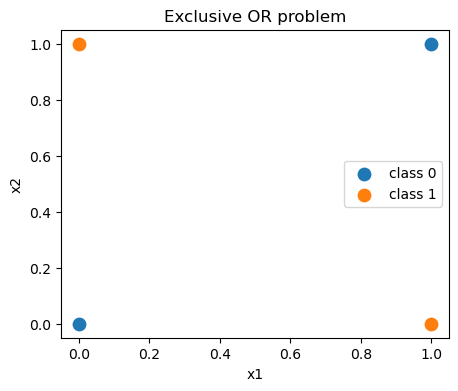

In [13]:
# ============================================================
# Section 4 - Exclusive OR dataset
# ============================================================
# This is a small nonlinear toy dataset used to show why
# hidden layers are useful.
# ============================================================

X_xor = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y_xor = np.array([
    [0.0],
    [1.0],
    [1.0],
    [0.0]
])

plt.figure(figsize=(5, 4))
plt.scatter(X_xor[y_xor[:, 0] == 0, 0], X_xor[y_xor[:, 0] == 0, 1], s=80, label="class 0")
plt.scatter(X_xor[y_xor[:, 0] == 1, 0], X_xor[y_xor[:, 0] == 1, 1], s=80, label="class 1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Exclusive OR problem")
plt.legend()
plt.show()

The plot shows that the two classes are arranged diagonally.

This is why a single linear boundary cannot solve the problem.

The next code cell defines helper functions to initialize parameters, update parameters, and train the network using NumPy.

This is the full training loop from scratch.

In [14]:
# ============================================================
# Section 4 - NumPy training functions
# ============================================================
# We initialize parameters, run forward and backward passes,
# and update parameters with Gradient Descent.
# ============================================================

def initialize_parameters_numpy(n_input_features, n_hidden_units, seed=42):
    rng = np.random.default_rng(seed)

    W1 = rng.normal(0.0, 0.5, size=(n_input_features, n_hidden_units))
    b1 = np.zeros((1, n_hidden_units))

    W2 = rng.normal(0.0, 0.5, size=(n_hidden_units, 1))
    b2 = np.zeros((1, 1))

    return W1, b1, W2, b2

def update_parameters_numpy(W1, b1, W2, b2, gradients, learning_rate):
    W1 = W1 - learning_rate * gradients["dW1"]
    b1 = b1 - learning_rate * gradients["db1"]
    W2 = W2 - learning_rate * gradients["dW2"]
    b2 = b2 - learning_rate * gradients["db2"]

    return W1, b1, W2, b2

def train_numpy_neural_network(
    X,
    y,
    n_hidden_units=4,
    learning_rate=0.5,
    n_epochs=5000,
    seed=42
):
    # Initialize all trainable parameters of the network:
    # W1, b1 for the hidden layer
    # W2, b2 for the output layer
    W1, b1, W2, b2 = initialize_parameters_numpy(
        n_input_features=X.shape[1],
        n_hidden_units=n_hidden_units,
        seed=seed
    )

    # Store the loss value at each epoch
    loss_history = []

    # Repeat the training procedure for a fixed number of epochs
    for epoch in range(n_epochs):

        # Forward pass:
        # compute predicted probabilities and save intermediate values
        y_prob, cache = forward_pass_numpy(X, W1, b1, W2, b2)

        # Compute Binary Cross-Entropy loss
        loss = binary_cross_entropy_numpy(y, y_prob)

        # Backward pass:
        # compute gradients for W1, b1, W2, and b2
        gradients = backward_pass_numpy(y, W2, cache)

        # Gradient Descent update:
        # move each parameter in the direction that reduces the loss
        W1, b1, W2, b2 = update_parameters_numpy(
            W1,
            b1,
            W2,
            b2,
            gradients,
            learning_rate
        )

        # Save the loss to visualize training later
        loss_history.append(loss)

    # Store the final trained parameters
    parameters = {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }


    return parameters, loss_history

The next code cell trains the Neural Network (NN) from scratch on the exclusive OR (XOR) dataset.

We then inspect the final probabilities and predicted labels.

In [15]:
# ============================================================
# Section 4 - Train on Exclusive OR
# ============================================================
# This training loop uses only NumPy. No PyTorch is used here.
# ============================================================

xor_parameters, xor_loss_history = train_numpy_neural_network(
    X_xor,
    y_xor,
    n_hidden_units=4,
    learning_rate=0.5,
    n_epochs=5000,
    seed=42
)

xor_prob, _ = forward_pass_numpy(
    X_xor,
    xor_parameters["W1"],
    xor_parameters["b1"],
    xor_parameters["W2"],
    xor_parameters["b2"]
)

xor_pred = (xor_prob >= 0.5).astype(int)

print("Predicted probabilities:")
print(xor_prob.ravel())

print("\nPredicted labels:")
print(xor_pred.ravel())

print("\nTrue labels:")
print(y_xor.ravel())

Predicted probabilities:
[0.00100655 0.99983819 0.9998385  0.00100655]

Predicted labels:
[0 1 1 0]

True labels:
[0. 1. 1. 0.]


The predicted probabilities should be close to the correct binary labels.

This shows that a small Neural Network (NN) with a hidden layer can learn a nonlinear pattern.

The next code cell plots the training loss.

A decreasing loss indicates that Gradient Descent (GD) is successfully updating the parameters.

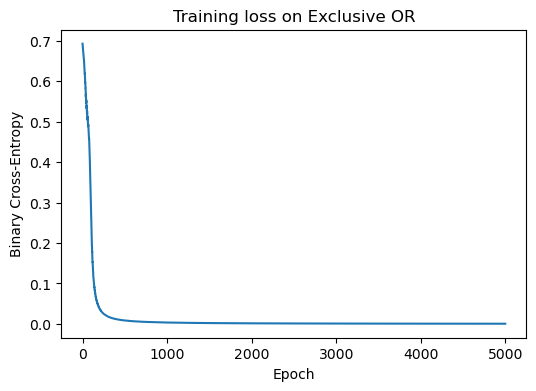

In [16]:
# ============================================================
# Section 4 - Plot loss curve
# ============================================================
# The loss curve shows whether optimization is working.
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(xor_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("Training loss on Exclusive OR")
plt.show()

This plot connects directly to Lab 1 and Lab 2.

The model is trained by repeatedly reducing a loss. The only new element is that the gradients are propagated through a hidden layer.

### Exercises for Section 4

These exercises modify the training setup.

**Exercise 4.1**  
Train the exclusive OR (XOR) network with only 2 hidden units. Does it still solve the task?

**Exercise 4.2**  
Train with a smaller learning rate, such as `0.05`. How does the loss curve change?

**Exercise 4.3**  
Train for only 100 epochs. Is the model under-trained?

**Exercise 4.4**  
Explain why the exclusive OR (XOR) example is useful before moving to biological data.

4.1 preds: [1 1 1 0]   true: [0 1 1 0]   final loss: 0.4774247832124729


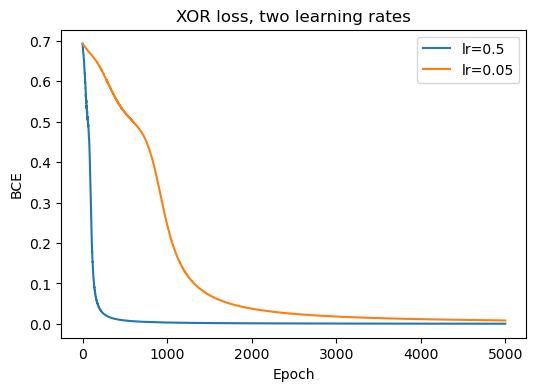

4.2 final loss with lr=0.05: 0.00864664926703581

4.3 probs: [0.27708312 0.65478377 0.96051426 0.27708312]   final loss: 0.29258824254360954


In [17]:
# Section 4 exercises

# 4.1 - XOR with 2 hidden units
params_2hid, hist_2hid = train_numpy_neural_network(
    X_xor, y_xor, n_hidden_units=2, learning_rate=0.5, n_epochs=5000, seed=42
)
prob_2hid, _ = forward_pass_numpy(
    X_xor, params_2hid["W1"], params_2hid["b1"], params_2hid["W2"], params_2hid["b2"]
)
print("4.1 preds:", (prob_2hid >= 0.5).astype(int).ravel(),
      "  true:", y_xor.ravel().astype(int),
      "  final loss:", hist_2hid[-1])

# 4.2 - smaller learning rate
_, hist_slow = train_numpy_neural_network(
    X_xor, y_xor, n_hidden_units=4, learning_rate=0.05, n_epochs=5000, seed=42
)
plt.figure(figsize=(6, 4))
plt.plot(xor_loss_history, label="lr=0.5")
plt.plot(hist_slow,        label="lr=0.05")
plt.xlabel("Epoch"); plt.ylabel("BCE"); plt.title("XOR loss, two learning rates")
plt.legend(); plt.show()
print("4.2 final loss with lr=0.05:", hist_slow[-1])

# 4.3 - only 100 epochs
params_short, hist_short = train_numpy_neural_network(
    X_xor, y_xor, n_hidden_units=4, learning_rate=0.5, n_epochs=100, seed=42
)
prob_short, _ = forward_pass_numpy(
    X_xor, params_short["W1"], params_short["b1"], params_short["W2"], params_short["b2"]
)
print("\n4.3 probs:", prob_short.ravel(), "  final loss:", hist_short[-1])


**4.1** Two hidden units is the bare minimum for XOR. It works with this seed and `lr=0.5`, but it's fragile: change the seed and the network can get stuck at chance.

**4.2** Smaller learning rate gives a slower, smoother loss curve and needs many more epochs. Big lr is faster but can oscillate or overshoot.

**4.3** After 100 epochs the loss is still high and predicted probabilities aren't close to 0/1. Under-trained.

**4.4** XOR is the simplest example a linear model can't solve. If the from-scratch net solves it, the forward pass, backward pass, and updates are all correct, so the same code can be trusted on real data.


## Section 5 — PyTorch in 15 minutes

We have now implemented the key ideas manually:

```text
forward pass
loss
backpropagation
parameter update
```

PyTorch does not replace the mathematics. It implements the same matrix operations and automatically tracks the computational graph.

When we call:

```python
loss.backward()
```

PyTorch computes gradients for all learnable parameters.

When we call:

```python
optimizer.step()
```

PyTorch updates the parameters using those gradients.

The goal of this section is to show the minimal PyTorch workflow before applying it to biological data.

The next code cell converts a NumPy array into a PyTorch tensor.

A tensor is similar to a NumPy array. The key difference is that PyTorch can keep track of the operations applied to tensors. When we later call `loss.backward()`, PyTorch uses this record of operations to compute the gradients needed to update the model parameters.

In [18]:
# ============================================================
# Section 5 - PyTorch tensors
# ============================================================
# We convert a NumPy array into a PyTorch tensor.
# ============================================================

x_numpy = np.array([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0]
])

x_tensor = torch.tensor(x_numpy, dtype=torch.float32)

print("NumPy array:")
print(x_numpy)

print("\nPyTorch tensor:")
print(x_tensor)

print("\nTensor shape:")
print(x_tensor.shape)

NumPy array:
[[1. 2. 3.]
 [4. 5. 6.]]

PyTorch tensor:
tensor([[1., 2., 3.],
        [4., 5., 6.]])

Tensor shape:
torch.Size([2, 3])


The next code cell introduces `nn.Linear()`.

A linear layer applies:

```text
output = input @ weights.T + bias
```

This is the PyTorch version of the weighted sum plus bias.

In [19]:
# ============================================================
# Section 5 - PyTorch linear layer
# ============================================================
# nn.Linear(in_features, out_features) transforms each row
# from in_features values to out_features values.
# ============================================================

linear_layer = nn.Linear(in_features=3, out_features=2)

linear_output = linear_layer(x_tensor)

print("Input shape:")
print(x_tensor.shape)

print("\nOutput shape:")
print(linear_output.shape)

print("\nLayer weights shape:")
print(linear_layer.weight.shape)

print("\nLayer bias shape:")
print(linear_layer.bias.shape)

Input shape:
torch.Size([2, 3])

Output shape:
torch.Size([2, 2])

Layer weights shape:
torch.Size([2, 3])

Layer bias shape:
torch.Size([2])


The output has two columns because the layer has two output units.

Notice that PyTorch stores the weight matrix with shape:

```text
out_features × in_features
```

This is why the weight matrix of this layer has shape `2 × 3`.

The next code cell builds a tiny Neural Network (NN) with PyTorch.

It has:

```text
3 input features → 4 hidden units → 1 output logit
```

The final output is called a logit. A logit is a raw score before applying the sigmoid function.

In [20]:
# ============================================================
# Section 5 - Tiny PyTorch Neural Network
# ============================================================
# nn.Sequential chains layers and activation functions.
# ============================================================

tiny_model = nn.Sequential(
    nn.Linear(3, 4),
    nn.ReLU(),
    nn.Linear(4, 1)
)

tiny_logits = tiny_model(x_tensor)
tiny_probabilities = torch.sigmoid(tiny_logits)

print("Tiny model:")
print(tiny_model)

print("\nLogits:")
print(tiny_logits)

print("\nProbabilities:")
print(tiny_probabilities)

Tiny model:
Sequential(
  (0): Linear(in_features=3, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
)

Logits:
tensor([[-0.8517],
        [-2.2093]], grad_fn=<AddmmBackward0>)

Probabilities:
tensor([[0.2991],
        [0.0989]], grad_fn=<SigmoidBackward0>)


The next code cell performs one loss computation and one backward pass.

`BCEWithLogitsLoss()` combines sigmoid and Binary Cross-Entropy (BCE) in a numerically stable way.

After `loss.backward()`, PyTorch stores gradients inside each parameter.

In [21]:
# ============================================================
# Section 5 - Loss and backward pass in PyTorch
# ============================================================
# This is the PyTorch version of computing gradients.
# ============================================================

y_tiny_torch = torch.tensor([
    [0.0],
    [1.0]
])

loss_function = nn.BCEWithLogitsLoss()

tiny_loss = loss_function(tiny_logits, y_tiny_torch)

tiny_model.zero_grad()
tiny_loss.backward()

print("Loss:")
print(tiny_loss.item())

print("\nGradient for the first layer weights:")
print(tiny_model[0].weight.grad)

Loss:
1.3344066143035889

Gradient for the first layer weights:
tensor([[0.6523, 0.7711, 0.8899],
        [0.3809, 0.4503, 0.5197],
        [0.2333, 0.2758, 0.3183],
        [0.4968, 0.5873, 0.6778]])


The next code cell performs one optimizer step.

The optimizer uses the gradients to update the model parameters.

This is the PyTorch equivalent of:

```text
parameter = parameter - learning_rate * gradient
```
Adam is a gradient-based optimizer. Like Gradient Descent (GD), it updates model parameters using gradients. However, instead of using the same fixed update rule for all parameters, Adam adapts the update size for each parameter based on the recent history of its gradients. This often makes training more stable and faster in practice.

In [22]:
# ============================================================
# Section 5 - Optimizer step
# ============================================================
# The optimizer updates the model parameters using gradients.
# ============================================================

optimizer = torch.optim.Adam(tiny_model.parameters(), lr=0.01)

print("First layer weights before update:")
print(tiny_model[0].weight.data)

optimizer.step()

print("\nFirst layer weights after update:")
print(tiny_model[0].weight.data)

First layer weights before update:
tensor([[ 0.5090, -0.4236,  0.5018],
        [ 0.1081,  0.4266,  0.0782],
        [ 0.2784, -0.0815,  0.4451],
        [ 0.0853, -0.2695,  0.1472]])

First layer weights after update:
tensor([[ 0.4990, -0.4336,  0.4918],
        [ 0.0981,  0.4166,  0.0682],
        [ 0.2684, -0.0915,  0.4351],
        [ 0.0753, -0.2795,  0.1372]])


The full PyTorch training loop repeats the same steps many times:

```text
1. forward pass
2. compute loss
3. clear old gradients
4. compute new gradients
5. update parameters
```

This is exactly the same logic as the NumPy training loop, but PyTorch computes the gradients automatically.

### Exercises for Section 5

These exercises make you connect NumPy and PyTorch.

**Exercise 5.1**  
Explain what `nn.Linear()` computes.

**Exercise 5.2**  
Explain what a logit is.

**Exercise 5.3**  
Explain why we use `BCEWithLogitsLoss()` instead of manually applying sigmoid before Binary Cross-Entropy (BCE).

**Exercise 5.4**  
Explain what `loss.backward()` and `optimizer.step()` do.

In [23]:
# Section 5 exercises
# Mostly conceptual. Small demo of nn.Linear below; written answers in markdown.

demo_layer = nn.Linear(3, 2)
demo_input = torch.tensor([[1.0, 2.0, 3.0]])
print("nn.Linear demo")
print("input shape :", demo_input.shape)
print("weight shape:", demo_layer.weight.shape)
print("bias shape  :", demo_layer.bias.shape)
print("output      :", demo_layer(demo_input))


nn.Linear demo
input shape : torch.Size([1, 3])
weight shape: torch.Size([2, 3])
bias shape  : torch.Size([2])
output      : tensor([[-0.6420,  0.1655]], grad_fn=<AddmmBackward0>)


**5.1** `nn.Linear(in, out)` stores a weight matrix `W` of shape `(out, in)` and a bias of shape `(out,)`, and computes `x @ W.T + b`. Same "weighted sum + bias" as logistic regression, vectorized to many outputs.

**5.2** A logit is the raw output of the final linear layer, before the sigmoid. Sigmoid turns it into a probability in (0, 1).

**5.3** `BCEWithLogitsLoss` combines sigmoid and BCE into one numerically stable formula. Doing sigmoid then `log(...)` by hand can overflow or hit `log(0)` for extreme logits.

**5.4**
- `loss.backward()` runs autograd from `loss` and fills in `param.grad` for every parameter with `requires_grad=True`.
- `optimizer.step()` uses those gradients to update parameters. Plain SGD does `param -= lr * param.grad`; Adam is an adaptive version.


## Section 6 — Load and explore the biological data matrix

Now we move to the real biological classification task.

We load the single-cell RNA-seq dataset and extract:

- `X_raw`: the gene expression feature matrix;
- `y`: the binary neuronal/non-neuronal label.

Remember the Machine Learning (ML) convention:

```text
rows = samples
columns = features
```

In this lab:

```text
rows = cells
columns = genes
```

This orientation is important. In many biological workflows, expression matrices are stored as genes × cells. For Machine Learning (ML), we usually need cells × genes.

The next code cell loads the dataset and checks that the required columns are present.

All columns starting with `gene_` are treated as gene expression features. The target is the `label` column.

In [24]:
# ============================================================
# Section 6 - Load biological dataset
# ============================================================
# We load the single-cell RNA-seq dataset and define X_raw and y.
# ============================================================

data_path = Path("zeisel_neuron_classification.csv")

if not data_path.exists():
    raise FileNotFoundError(
        "Could not find 'zeisel_neuron_classification.csv'. "
        "Place it in the same folder as this notebook or update data_path."
    )

data = pd.read_csv(data_path)

required_columns = ["cell_id", "cell_type", "label"]
missing = [col for col in required_columns if col not in data.columns]

if len(missing) > 0:
    raise ValueError(f"Missing required columns: {missing}")

gene_columns = [col for col in data.columns if col.startswith("gene_")]

if len(gene_columns) == 0:
    raise ValueError("No gene expression columns found. Expected columns starting with 'gene_'.")

X_raw = data[gene_columns].to_numpy(dtype=np.float32)
y = data["label"].to_numpy(dtype=np.float32).reshape(-1, 1)

print("Dataset shape:", data.shape)
print("Input matrix shape:", X_raw.shape)
print("Target vector shape:", y.shape)
print("Number of gene features:", len(gene_columns))

display(data.head())

Dataset shape: (3005, 103)
Input matrix shape: (3005, 100)
Target vector shape: (3005, 1)
Number of gene features: 100


,cell_id,cell_type,label,gene_001__Plp1,gene_002__Trf,gene_003__Mal,gene_004__Apod,gene_005__Mog,gene_006__Mbp,gene_007__Car2,...,gene_091__Pdlim2,gene_092__Eno2,gene_093__Vsnl1,gene_094__Ncdn,gene_095__Scn2a1,gene_096__Rasgrp1,gene_097__Gstp1,gene_098__Npy,gene_099__Rgs4,gene_100__Gabra1
0,1772071015_C02,interneurons,1,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,3.911539,4.302407,2.811624,3.174352,1.878092,3.911539,6.858766,0.000000,4.147656
1,1772071017_G12,interneurons,1,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,4.410823,5.771367,2.639523,3.434108,0.725878,0.725878,0.000000,3.248047,5.017366
2,1772071017_A05,interneurons,1,0.544784,0.0,0.0,0.0,0.0,0.0,1.719845,...,0.0,3.210769,3.742831,2.978567,3.586314,0.000000,1.907972,5.808803,0.000000,3.791445
3,1772071014_B06,interneurons,1,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,4.054166,6.037357,2.326120,3.434741,1.225388,2.856957,0.000000,0.000000,5.935889
4,1772067065_H06,interneurons,1,0.756446,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,3.951942,4.569715,2.703675,4.242025,0.000000,2.152709,0.000000,0.000000,5.811109


The output confirms that the input matrix has cells on the rows and gene features on the columns.

The `label` vector has one binary label for each cell.

The next code cell visualizes the class balance.

Class balance matters because accuracy can be misleading if one class is much more frequent than the other.

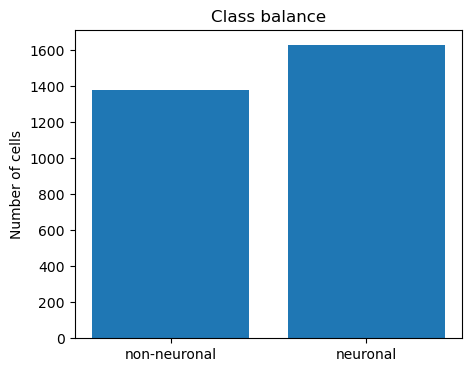

Class counts:
0.0    1377
1.0    1628
Name: count, dtype: int64


In [25]:
# ============================================================
# Section 6 - Class balance
# ============================================================
# We count how many cells belong to each class.
# ============================================================

class_counts = pd.Series(y.ravel()).value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(["non-neuronal", "neuronal"], [class_counts.loc[0.0], class_counts.loc[1.0]])
plt.ylabel("Number of cells")
plt.title("Class balance")
plt.show()

print("Class counts:")
print(class_counts)

If the classes are reasonably balanced, accuracy is easier to interpret. If one class dominates, we must rely more strongly on precision, recall, and the confusion matrix.

The next code cell standardizes the gene expression features.

Standardization transforms each gene feature so that it has approximately:

```text
mean = 0
standard deviation = 1
```

This is useful because Neural Networks (NNs) are optimized using gradient-based methods. When input features have very different scales, optimization can become unstable or slow.

In [26]:
# ============================================================
# Section 6 - Standardize gene expression features
# ============================================================
# Each gene feature is centered and scaled.
# ============================================================

X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)

X = (X_raw - X_mean) / (X_std + 1e-8)

print("Mean of the first 5 standardized features:")
print(X[:, :5].mean(axis=0))

print("\nStandard deviation of the first 5 standardized features:")
print(X[:, :5].std(axis=0))

Mean of the first 5 standardized features:
[-2.031120e-08  4.062240e-08 -1.218672e-07 -1.218672e-07 -4.062240e-08]

Standard deviation of the first 5 standardized features:
[0.99999994 1.         1.         1.         1.        ]


The first five standardized features have mean close to 0 and standard deviation close to 1.

Small deviations are expected because of numerical precision.

The next code cell uses Principal Component Analysis (PCA) to summarize all gene features into two dimensions.

Principal Component Analysis (PCA) is unsupervised. It does not use the neuronal/non-neuronal labels to compute the axes.

The purpose here is exploratory:

> Do the gene expression profiles show visible structure related to the biological labels?

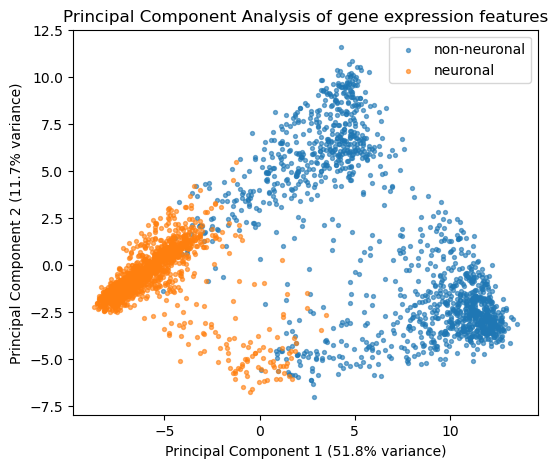

In [27]:
# ============================================================
# Section 6 - Principal Component Analysis visualization
# ============================================================
# PCA summarizes the high-dimensional gene expression matrix
# into two dimensions for visualization.
# ============================================================

U, S, Vt = np.linalg.svd(X, full_matrices=False)
X_pca = X @ Vt[:2].T

explained_variance = (S ** 2) / (X.shape[0] - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[y.ravel() == 0, 0], X_pca[y.ravel() == 0, 1], s=8, alpha=0.6, label="non-neuronal")
plt.scatter(X_pca[y.ravel() == 1, 0], X_pca[y.ravel() == 1, 1], s=8, alpha=0.6, label="neuronal")
plt.xlabel(f"Principal Component 1 ({explained_variance_ratio[0] * 100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({explained_variance_ratio[1] * 100:.1f}% variance)")
plt.title("Principal Component Analysis of gene expression features")
plt.legend()
plt.show()

The two classes occupy different regions in the Principal Component Analysis (PCA) plot, this suggests that gene expression contains useful information for classification.

However, incomplete separation does not mean that classification will fail. Principal Component Analysis (PCA) is not optimized to separate the labels.

### Exercises for Section 6

These exercises extend data exploration beyond the plots already shown.

**Exercise 6.1**  
Find the three genes with the largest variance before standardization. Plot their expression distributions by class.

**Exercise 6.2**  
Repeat the Principal Component Analysis (PCA) plot using the first and third principal components instead of the first two.

**Exercise 6.3**  
Compute the total variance explained by the first 5 principal components.

**Exercise 6.4**  
Discuss whether the Principal Component Analysis (PCA) plot alone is sufficient to judge classifier performance.

6.1 top genes: ['gene_001__Plp1', 'gene_002__Trf', 'gene_003__Mal']
6.1 variances: [14.975004   9.7500515  8.970914 ]


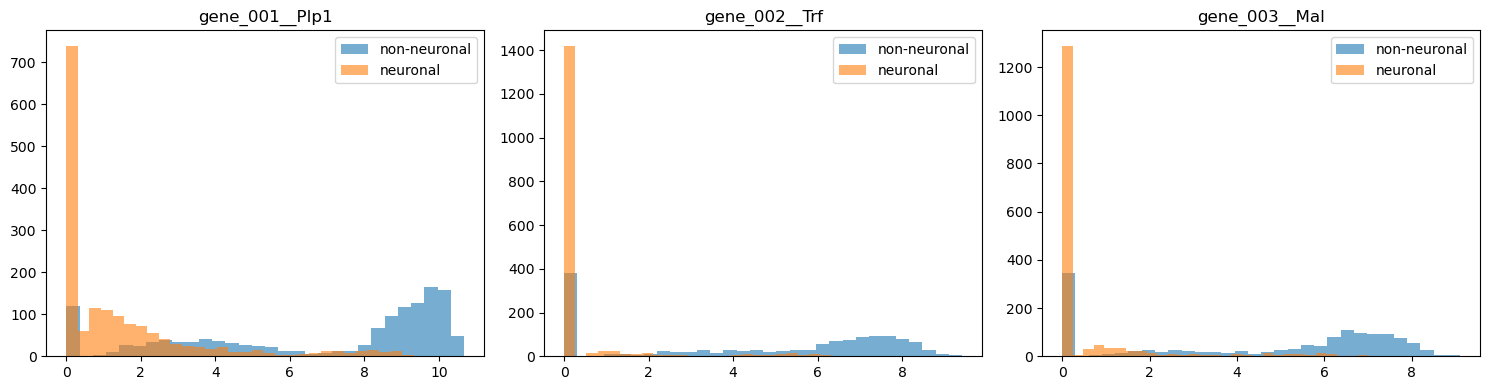

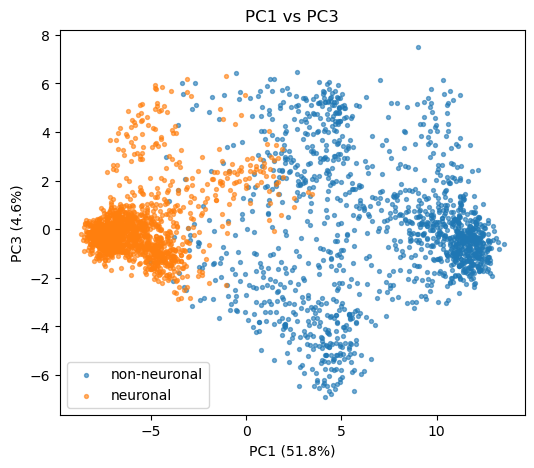

PC1: 51.77%
PC2: 11.69%
PC3: 4.58%
PC4: 3.42%
PC5: 1.88%
Total: 73.35%


In [28]:
# Section 6 exercises

# 6.1 - top 3 genes by raw variance, per-class histograms
gene_variances = X_raw.var(axis=0)
top3_indices = np.argsort(gene_variances)[-3:][::-1]
top3_names = [gene_columns[i] for i in top3_indices]
print("6.1 top genes:", top3_names)
print("6.1 variances:", gene_variances[top3_indices])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for k, gene_idx in enumerate(top3_indices):
    axes[k].hist(X_raw[y.ravel() == 0, gene_idx], bins=30, alpha=0.6, label="non-neuronal")
    axes[k].hist(X_raw[y.ravel() == 1, gene_idx], bins=30, alpha=0.6, label="neuronal")
    axes[k].set_title(top3_names[k])
    axes[k].legend()
plt.tight_layout(); plt.show()

# 6.2 - PCA scatter with PC1 vs PC3
X_pc1_pc3 = X @ Vt[[0, 2]].T
plt.figure(figsize=(6, 5))
plt.scatter(X_pc1_pc3[y.ravel() == 0, 0], X_pc1_pc3[y.ravel() == 0, 1],
            s=8, alpha=0.6, label="non-neuronal")
plt.scatter(X_pc1_pc3[y.ravel() == 1, 0], X_pc1_pc3[y.ravel() == 1, 1],
            s=8, alpha=0.6, label="neuronal")
plt.xlabel(f"PC1 ({explained_variance_ratio[0]*100:.1f}%)")
plt.ylabel(f"PC3 ({explained_variance_ratio[2]*100:.1f}%)")
plt.title("PC1 vs PC3")
plt.legend(); plt.show()

# 6.3 - cumulative variance of first 5 PCs
first5 = explained_variance_ratio[:5]
for i, r in enumerate(first5):
    print(f"PC{i+1}: {r*100:.2f}%")
print("Total:", f"{first5.sum()*100:.2f}%")


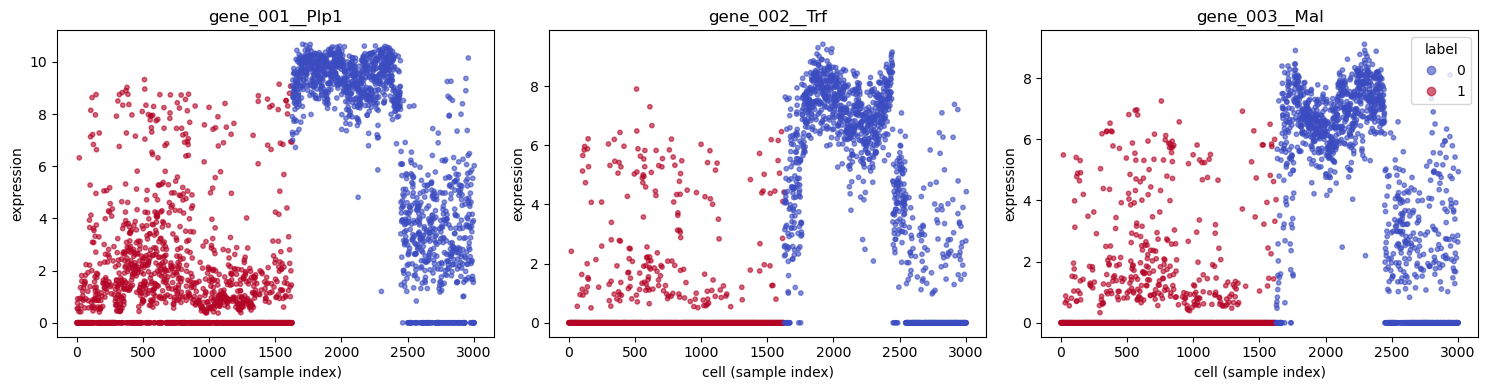

In [29]:
# --- Supplementary view (folded in from RAF's solution) ---
# Alternative to the per-class histograms above: a per-sample scatter of the
# top-3 variance genes, one point per cell (x = sample index), colored by class.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for k, gene_idx in enumerate(top3_indices):
    sc = axes[k].scatter(range(X_raw.shape[0]), X_raw[:, gene_idx],
                         c=y.ravel(), cmap="coolwarm", alpha=0.6, s=10)
    axes[k].set_title(top3_names[k])
    axes[k].set_xlabel("cell (sample index)")
    axes[k].set_ylabel("expression")
axes[2].legend(*sc.legend_elements(), title="label", loc="upper right")
plt.tight_layout(); plt.show()


**6.1** Top-variance genes printed above. Genes whose per-class distributions look very different should be useful for classification; those that overlap heavily won't do much work.

**6.2** PC1 still captures the broadest structure. PC3 holds less variance than PC2, so the picture usually looks more mixed. PCA isn't optimizing for class separation.

**6.3** Cumulative percentage printed above. With single-cell data the first 5 PCs often catch only a modest share, since variance is spread across many directions.

**6.4** No. PCA finds directions of max variance, not directions that separate classes. Two classes can look mixed in 2-D PCA and still be perfectly separable in the full feature space.


## Section 7 — Train, validation, and test split

We split the dataset into three parts:

- training set: used to update the model parameters;
- validation set: used to compare model configurations;
- test set: used only at the end for final evaluation.

The validation set tells us whether the model is likely to generalize beyond the training data.

The test set should not be used while choosing the model. If we use it repeatedly during model development, it stops being an independent final evaluation.

The next code cell implements a stratified split.

A stratified split preserves approximately the same proportion of neuronal and non-neuronal cells in the training, validation, and test sets.

In [30]:
# ============================================================
# Section 7 - Stratified train, validation, and test split
# ============================================================
# The split preserves class proportions across the three sets.
# ============================================================

def stratified_three_way_split(X, y, train_fraction=0.60, val_fraction=0.20, seed=42):
    rng = np.random.default_rng(seed)

    # Flatten labels to simplify indexing
    y_flat = y.ravel()

    train_indices = []
    val_indices = []
    test_indices = []

    # Split each class separately
    for label in np.unique(y_flat):
        label_indices = np.where(y_flat == label)[0]
        rng.shuffle(label_indices)

        n_total = len(label_indices)
        n_train = int(round(train_fraction * n_total))
        n_val = int(round(val_fraction * n_total))

        train_indices.extend(label_indices[:n_train])
        val_indices.extend(label_indices[n_train:n_train + n_val])
        test_indices.extend(label_indices[n_train + n_val:])

    # Convert lists to arrays
    train_indices = np.array(train_indices)
    val_indices = np.array(val_indices)
    test_indices = np.array(test_indices)

    # Shuffle final indices so classes are mixed
    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    rng.shuffle(test_indices)

    return train_indices, val_indices, test_indices

# Create stratified indices for train, validation, and test sets
train_idx, val_idx, test_idx = stratified_three_way_split(
    X,
    y,
    train_fraction=0.60,
    val_fraction=0.20,
    seed=42
)

# Subset X and y using the generated indices
X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

X_test = X[test_idx]
y_test = y[test_idx]

# Inspect split dimensions
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

# Check that class proportions are preserved
print("\nTraining class counts:", np.unique(y_train, return_counts=True))
print("Validation class counts:", np.unique(y_val, return_counts=True))
print("Test class counts:", np.unique(y_test, return_counts=True))

X_train shape: (1803, 100)
X_val shape: (601, 100)
X_test shape: (601, 100)

Training class counts: (array([0., 1.], dtype=float32), array([826, 977]))
Validation class counts: (array([0., 1.], dtype=float32), array([275, 326]))
Test class counts: (array([0., 1.], dtype=float32), array([276, 325]))


The row counts differ because cells are split across training, validation, and test sets.

The number of columns remains the same because all sets use the same gene expression features.

The next code cell converts NumPy arrays into PyTorch tensors.

PyTorch models work with tensors. A tensor is similar to a NumPy array, but it can also store information needed for automatic differentiation.

In [31]:
# ============================================================
# Section 7 - Convert arrays to PyTorch tensors
# ============================================================
# PyTorch models expect tensor inputs.
# ============================================================

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)

X_train_tensor shape: torch.Size([1803, 100])
y_train_tensor shape: torch.Size([1803, 1])


The model will receive `X_train_tensor` as input and will learn to predict `y_train_tensor`.

### Exercises for Section 7

These exercises focus on the role of data splitting.

**Exercise 7.1**  
Compute the percentage of neuronal cells in the training, validation, and test sets.

**Exercise 7.2**  
Explain why the validation set should not be used to update model parameters.

**Exercise 7.3**  
Create a deliberately non-stratified split and compare class proportions with the stratified split.

**Exercise 7.4**  
Explain why the test set should be used only at the end of the lab.

In [32]:
# Section 7 exercises

def percent_neuronal(y_array):
    return 100.0 * y_array.ravel().mean()

# 7.1 - class proportions per split
print("7.1 train: %.2f%%  val: %.2f%%  test: %.2f%% neuronal" % (
    percent_neuronal(y_train), percent_neuronal(y_val), percent_neuronal(y_test)
))

# 7.3 - deliberately non-stratified split
rng_naive = np.random.default_rng(0)
all_indices = np.arange(X.shape[0])
rng_naive.shuffle(all_indices)
n_train_naive = int(0.60 * len(all_indices))
n_val_naive   = int(0.20 * len(all_indices))
train_idx_naive = all_indices[:n_train_naive]
val_idx_naive   = all_indices[n_train_naive:n_train_naive + n_val_naive]
test_idx_naive  = all_indices[n_train_naive + n_val_naive:]

print("\n7.3 stratified vs non-stratified % neuronal:")
print("  train:", percent_neuronal(y_train),         "vs", percent_neuronal(y[train_idx_naive]))
print("  val:  ", percent_neuronal(y_val),           "vs", percent_neuronal(y[val_idx_naive]))
print("  test: ", percent_neuronal(y_test),          "vs", percent_neuronal(y[test_idx_naive]))


7.1 train: 54.19%  val: 54.24%  test: 54.08% neuronal

7.3 stratified vs non-stratified % neuronal:
  train: 54.187466 vs 53.022743
  val:   54.242928 vs 58.23627
  test:  54.07654 vs 53.57737


**7.1** The three percentages should be very close. That's the point of stratification.

**7.2** If we trained on the validation set, the model would fit it and we'd lose the "unseen" check, so we couldn't spot overfitting.

**7.3** Without stratification, class proportions drift from the overall rate, especially in the smaller val/test splits. Small effect here, much worse on imbalanced datasets.

**7.4** Every time you peek at the test score and then tweak the model, the test set becomes a second validation set. The test number stops being honest. Touch it once, at the end.


## Section 8 — Biological Neural Network with PyTorch

We now build a small fully connected Neural Network (NN) for the biological classification task.

The architecture is:

```text
gene expression features → hidden layer → Rectified Linear Unit → output logit
```

The output logit is a raw score.

During training, we use `BCEWithLogitsLoss`, which combines:

```text
logit → sigmoid → Binary Cross-Entropy
```

in a numerically stable way.

We use one output unit because this is a binary classification task.

The next code cell defines the Neural Network (NN).

The model has:

- one input layer, represented by the gene expression features;
- one hidden fully connected layer;
- one Rectified Linear Unit (ReLU) activation;
- one output layer producing one logit per cell.

In [33]:
# ============================================================
# Section 8 - Define a biological Neural Network
# ============================================================
# The model maps gene expression features to one output logit.
# ============================================================

class GeneExpressionNeuralNetwork(nn.Module):
    def __init__(self, n_input_features, n_hidden_units=16):
        super().__init__()

        self.hidden = nn.Linear(n_input_features, n_hidden_units)
        self.activation = nn.ReLU()
        self.output = nn.Linear(n_hidden_units, 1)

    def forward(self, x):
        z1 = self.hidden(x)
        a1 = self.activation(z1)
        logits = self.output(a1)
        return logits

n_input_features = X_train.shape[1]

model = GeneExpressionNeuralNetwork(
    n_input_features=n_input_features,
    n_hidden_units=16
)

print(model)

GeneExpressionNeuralNetwork(
  (hidden): Linear(in_features=100, out_features=16, bias=True)
  (activation): ReLU()
  (output): Linear(in_features=16, out_features=1, bias=True)
)


The printed model shows the sequence of operations used in the forward pass.

The hidden layer transforms the gene expression features into 16 hidden activations. The output layer transforms those activations into one logit per cell.

The next code cell counts the number of learnable parameters.

A learnable parameter is a number that the model updates during training. In this model, learnable parameters are weights and biases.

Counting parameters is important because a model with more parameters is more flexible, but also more likely to overfit if the dataset is small.

In [34]:
# ============================================================
# Section 8 - Count learnable parameters
# ============================================================
# We inspect all weights and biases in the model.
# ============================================================

def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

n_parameters = count_parameters(model)

print("Number of input features:", n_input_features)
print("Number of learnable parameters:", n_parameters)

for name, parameter in model.named_parameters():
    print(name, tuple(parameter.shape), parameter.numel())

Number of input features: 100
Number of learnable parameters: 1633
hidden.weight (16, 100) 1600
hidden.bias (16,) 16
output.weight (1, 16) 16
output.bias (1,) 1


The output shows how many parameters are learned in each layer.

The first layer usually contains most parameters because each hidden neuron receives one weight from each input gene.

The next code cell performs a forward pass on a small batch of cells.

A forward pass means that we send input data through the model to compute the output.

We inspect:

- hidden linear scores;
- hidden activations;
- output logits;
- output probabilities.

In [35]:
# ============================================================
# Section 8 - Inspect a forward pass
# ============================================================
# Before training, predictions are based on random weights.
# ============================================================

X_batch = X_train_tensor[:5]

with torch.no_grad():
    z1 = model.hidden(X_batch)
    a1 = model.activation(z1)
    logits = model.output(a1)
    probabilities = torch.sigmoid(logits)

print("Input batch shape:", X_batch.shape)
print("Hidden linear scores shape:", z1.shape)
print("Hidden activations shape:", a1.shape)
print("Output logits shape:", logits.shape)
print("Output probabilities shape:", probabilities.shape)

print("\nOutput probabilities:")
print(probabilities.numpy().ravel())

Input batch shape: torch.Size([5, 100])
Hidden linear scores shape: torch.Size([5, 16])
Hidden activations shape: torch.Size([5, 16])
Output logits shape: torch.Size([5, 1])
Output probabilities shape: torch.Size([5, 1])

Output probabilities:
[0.47793174 0.46697655 0.39103124 0.51458275 0.49919325]


Before training, these probabilities are not meaningful biological predictions.

At this point the weights are random. Training will update the weights to reduce the classification loss.

### Exercises for Section 8

These exercises make you reason about architecture and parameters.

**Exercise 8.1**  
Change the hidden layer size from 16 to 4. How does the number of parameters change?

**Exercise 8.2**  
Change the hidden layer size from 16 to 64. How does the number of parameters change?

**Exercise 8.3**  
Write the formula for the number of parameters in this one-hidden-layer network.

**Exercise 8.4**  
Explain why the output layer has one unit for binary classification.

In [36]:
# Section 8 exercises

def build_and_count(hidden_size):
    m = GeneExpressionNeuralNetwork(n_input_features=n_input_features,
                                    n_hidden_units=hidden_size)
    return count_parameters(m)

# 8.1 and 8.2
print("8.1 hidden=4  ->", build_and_count(4),  "params")
print("8.2 hidden=64 ->", build_and_count(64), "params")
print("ref hidden=16 ->", build_and_count(16), "params")

# 8.3 - check the formula h * (f + 2) + 1
f = n_input_features
for h in [4, 16, 64]:
    print(f"h={h:3d}: formula = {h*(f+2)+1}, direct = {build_and_count(h)}")


8.1 hidden=4  -> 409 params
8.2 hidden=64 -> 6529 params
ref hidden=16 -> 1633 params
h=  4: formula = 409, direct = 409
h= 16: formula = 1633, direct = 1633
h= 64: formula = 6529, direct = 6529


**8.1** Going from 16 hidden units to 4 cuts the parameter count by roughly a factor of 4. The first layer dominates: its size is `f · h`.

**8.2** Going from 16 to 64 multiplies the count by roughly 4 for the same reason.

**8.3** With `f` input features and `h` hidden units:
- W1: `f·h`, b1: `h`
- W2: `h`, b2: `1`

Total = `h · (f + 2) + 1`. Matches PyTorch.

**8.4** Binary classification only needs `P(class 1)`; class 0 is `1 − p`, so a second output is redundant. For K classes we'd use K outputs and softmax.


## Section 9 — Training loop and backpropagation in PyTorch

Training a Neural Network (NN) follows the same logic as the models in the previous labs:

1. compute predictions with a forward pass;
2. compute the loss;
3. compute gradients with backpropagation;
4. update parameters with an optimizer.

In PyTorch:

```python
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

means:

- `optimizer.zero_grad()` clears old gradients;
- `loss.backward()` computes new gradients by backpropagation;
- `optimizer.step()` updates the model parameters.

This is the same training logic we implemented with NumPy, but PyTorch computes the gradients automatically.

The next code cell defines helper functions for:

- computing binary accuracy from logits;
- evaluating the model on a dataset;
- training the model for several epochs.

An epoch means one full pass through the training data.

In [37]:
# ============================================================
# Section 9 - Training and evaluation helper functions
# ============================================================
# These functions implement the PyTorch training workflow.
# ============================================================

def binary_accuracy_from_logits(logits, y_true):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= 0.5).float()
    return (predictions == y_true).float().mean().item()

def evaluate_model(model, X_tensor, y_tensor, loss_fn):
    model.eval()

    with torch.no_grad():
        logits = model(X_tensor)
        loss = loss_fn(logits, y_tensor)
        accuracy = binary_accuracy_from_logits(logits, y_tensor)

    return loss.item(), accuracy

def train_neural_network(
    model,
    X_train_tensor,
    y_train_tensor,
    X_val_tensor,
    y_val_tensor,
    learning_rate=0.001,
    n_epochs=200,
    weight_decay=0.0
):
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(n_epochs):
        model.train()

        logits = model(X_train_tensor)
        loss = loss_fn(logits, y_train_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss, train_accuracy = evaluate_model(
            model,
            X_train_tensor,
            y_train_tensor,
            loss_fn
        )
        val_loss, val_accuracy = evaluate_model(
            model,
            X_val_tensor,
            y_val_tensor,
            loss_fn
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

    return history

The next code cell trains the first Neural Network (NN) on the biological dataset.

We track both training and validation performance.

The training curve tells us whether the model is learning from the data used for optimization.  
The validation curve tells us whether the model is likely to generalize to unseen cells.

In [38]:
# ============================================================
# Section 9 - Train the biological Neural Network
# ============================================================
# We train the model and store training/validation curves.
# ============================================================

torch.manual_seed(42)

model = GeneExpressionNeuralNetwork(
    n_input_features=n_input_features,
    n_hidden_units=16
)

history = train_neural_network(
    model,
    X_train_tensor,
    y_train_tensor,
    X_val_tensor,
    y_val_tensor,
    learning_rate=0.001,
    n_epochs=200,
    weight_decay=0.0
)

print("Final training loss:", history["train_loss"][-1])
print("Final validation loss:", history["val_loss"][-1])
print("Final training accuracy:", history["train_accuracy"][-1])
print("Final validation accuracy:", history["val_accuracy"][-1])

Final training loss: 0.043168455362319946
Final validation loss: 0.05089711770415306
Final training accuracy: 0.9855796098709106
Final validation accuracy: 0.9850249290466309


The final losses and accuracies summarize the state of the model after training.

A good sign is that both training and validation loss decrease, and that validation accuracy is close to training accuracy.

The next code cell plots the loss and accuracy curves.

These curves play the same role as the loss curves in Lab 1 and Lab 2. The difference is that the model now has hidden layers and more parameters.

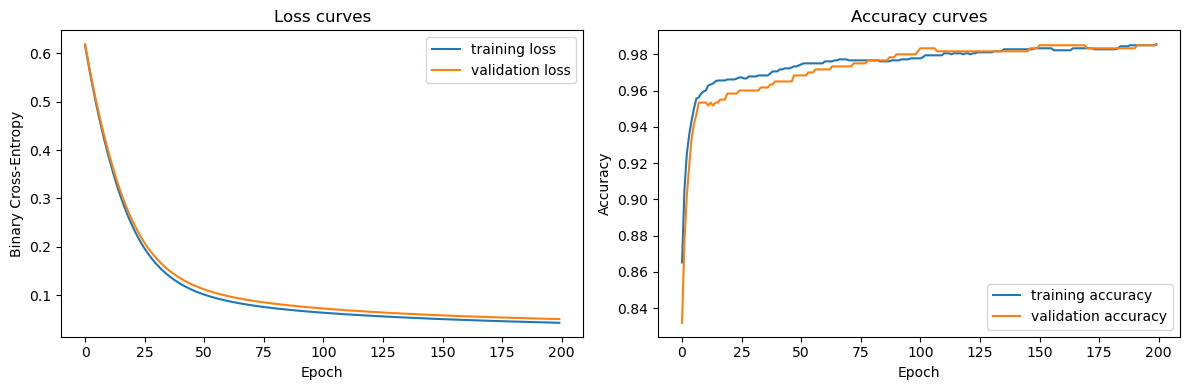

In [39]:
# ============================================================
# Section 9 - Plot training and validation curves
# ============================================================
# These curves are used to diagnose learning and overfitting.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="training loss")
axes[0].plot(history["val_loss"], label="validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy")
axes[0].set_title("Loss curves")
axes[0].legend()

axes[1].plot(history["train_accuracy"], label="training accuracy")
axes[1].plot(history["val_accuracy"], label="validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy curves")
axes[1].legend()

plt.tight_layout()
plt.show()

Training and validation curves improve together, the model is learning a pattern that generalizes.

If training performance improves while validation performance becomes worse, this may indicate overfitting. (This is not the case).

### Exercises for Section 9

These exercises explore optimization behavior rather than repeating the same training call.

**Exercise 9.1**  
Train the same architecture with a learning rate of `0.01`. Compare the loss curve with the original one.

**Exercise 9.2**  
Train the same architecture for only 20 epochs. Does the model appear under-trained?

**Exercise 9.3**  
Print the gradient norm of the first layer after one backward pass.

**Exercise 9.4**  
Explain in words what `optimizer.zero_grad()`, `loss.backward()`, and `optimizer.step()` do.

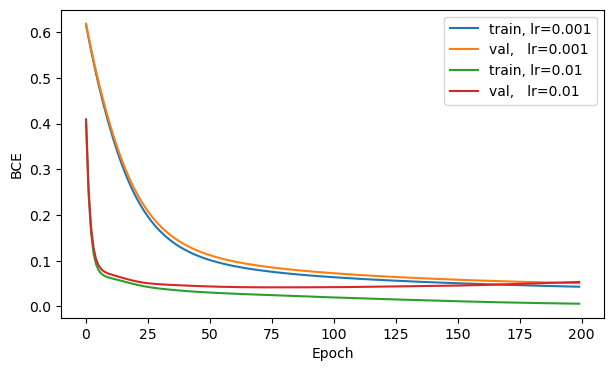

9.1 final val loss   lr=0.001: 0.05089711770415306
9.1 final val loss   lr=0.01 : 0.05359983444213867

9.2 after 20 epochs  train loss: 0.2520613968372345  val acc: 0.9584026336669922
9.2 after 200 epochs val acc: 0.9850249290466309

9.3 first-layer gradient norm: 0.8624087572097778


In [40]:
# Section 9 exercises

# 9.1 - lr=0.01
torch.manual_seed(42)
model_lr_high = GeneExpressionNeuralNetwork(n_input_features=n_input_features, n_hidden_units=16)
history_lr_high = train_neural_network(
    model_lr_high, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor,
    learning_rate=0.01, n_epochs=200, weight_decay=0.0
)
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"],         label="train, lr=0.001")
plt.plot(history["val_loss"],           label="val,   lr=0.001")
plt.plot(history_lr_high["train_loss"], label="train, lr=0.01")
plt.plot(history_lr_high["val_loss"],   label="val,   lr=0.01")
plt.xlabel("Epoch"); plt.ylabel("BCE"); plt.legend(); plt.show()
print("9.1 final val loss   lr=0.001:", history["val_loss"][-1])
print("9.1 final val loss   lr=0.01 :", history_lr_high["val_loss"][-1])

# 9.2 - 20 epochs only
torch.manual_seed(42)
model_short = GeneExpressionNeuralNetwork(n_input_features=n_input_features, n_hidden_units=16)
history_short = train_neural_network(
    model_short, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor,
    learning_rate=0.001, n_epochs=20, weight_decay=0.0
)
print("\n9.2 after 20 epochs  train loss:", history_short["train_loss"][-1],
      " val acc:", history_short["val_accuracy"][-1])
print("9.2 after 200 epochs val acc:", history["val_accuracy"][-1])

# 9.3 - first-layer gradient norm
torch.manual_seed(42)
model_grad = GeneExpressionNeuralNetwork(n_input_features=n_input_features, n_hidden_units=16)
loss_fn_grad = nn.BCEWithLogitsLoss()
loss_grad = loss_fn_grad(model_grad(X_train_tensor), y_train_tensor)
model_grad.zero_grad()
loss_grad.backward()
grad_norm = torch.sqrt((model_grad.hidden.weight.grad ** 2).sum()).item()
print("\n9.3 first-layer gradient norm:", grad_norm)


**9.1** Bigger lr drops the loss faster early but can become noisy or diverge. Smaller lr is slower but smoother. The two final val losses above show which won here.

**9.2** Loss higher and val accuracy lower after 20 epochs than after 200. Under-trained.

**9.3** The printed value is the L2 norm of `∂loss/∂W1`. Tiny values mean vanishing gradients (no learning), large values mean exploding gradients (instability).

**9.4**
- `optimizer.zero_grad()` resets `param.grad` to zero. PyTorch accumulates gradients, so without this they'd pile up across iterations.
- `loss.backward()` runs autograd and fills in `param.grad` for every trainable parameter.
- `optimizer.step()` uses those gradients to update parameters. For Adam, an adaptive version of `param -= lr * param.grad`.


## Section 10 — Evaluation on test data

After training and choosing a model, we evaluate it on the test set.

The test set was not used for parameter updates or model selection. It gives a final estimate of performance on unseen cells.

For binary classification, we evaluate:

- test loss;
- test accuracy;
- confusion matrix;
- precision;
- recall;
- distribution of predicted probabilities.

The next code cell computes test loss and test accuracy.

It also extracts predicted probabilities for the neuronal class.

In [41]:
# ============================================================
# Section 10 - Test set evaluation
# ============================================================
# We evaluate the trained model on unseen test cells.
# ============================================================

loss_fn = nn.BCEWithLogitsLoss()

test_loss, test_accuracy = evaluate_model(
    model,
    X_test_tensor,
    y_test_tensor,
    loss_fn
)

with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_probabilities = torch.sigmoid(test_logits)
    test_predictions = (test_probabilities >= 0.5).float()

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 0.052692241966724396
Test accuracy: 0.9750415682792664


The test accuracy gives the fraction of test cells classified correctly.

However, accuracy alone does not show which type of error the model makes. For that, we inspect the confusion matrix.

The next code cell computes and plots the confusion matrix.

For this task:

```text
false positive = non-neuronal cell predicted as neuronal
false negative = neuronal cell predicted as non-neuronal
```

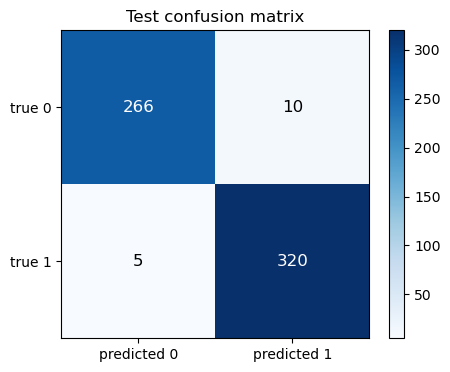

[[266  10]
 [  5 320]]


In [42]:
# ============================================================
# Section 10 - Confusion matrix
# ============================================================
# The confusion matrix separates correct and incorrect
# predictions by class.
# ============================================================

def confusion_matrix_binary_numpy(y_true, y_pred):
    y_true = y_true.ravel().astype(int)
    y_pred = y_pred.ravel().astype(int)

    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    return np.array([[tn, fp], [fn, tp]])

cm_test = confusion_matrix_binary_numpy(
    y_test,
    test_predictions.numpy()
)

plt.figure(figsize=(5, 4))
plt.imshow(cm_test, cmap="Blues")
plt.xticks([0, 1], ["predicted 0", "predicted 1"])
plt.yticks([0, 1], ["true 0", "true 1"])
plt.title("Test confusion matrix")
plt.colorbar()

threshold = cm_test.max() / 2

for i in range(2):
    for j in range(2):
        text_color = "white" if cm_test[i, j] > threshold else "black"
        plt.text(
            j,
            i,
            cm_test[i, j],
            ha="center",
            va="center",
            color=text_color,
            fontsize=12
        )

plt.show()

print(cm_test)

The diagonal entries are correct predictions. The off-diagonal entries are mistakes.

The confusion matrix is especially useful when the two types of error have different biological meanings.

The next code cell computes precision and recall.

Precision asks:

```text
Among cells predicted as neuronal, how many are truly neuronal?
```

Recall asks:

```text
Among truly neuronal cells, how many are recovered by the model?
```

In [43]:
# ============================================================
# Section 10 - Precision and recall
# ============================================================
# Precision and recall describe different error trade-offs.
# ============================================================

def precision_recall_from_confusion_matrix(cm):
    tn, fp = cm[0, 0], cm[0, 1]
    fn, tp = cm[1, 0], cm[1, 1]

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)

    return precision, recall

test_precision, test_recall = precision_recall_from_confusion_matrix(cm_test)

print("Test precision:", test_precision)
print("Test recall:", test_recall)

Test precision: 0.9696969696969667
Test recall: 0.9846153846153816


High precision means that few non-neuronal cells are incorrectly predicted as neuronal.

High recall means that most truly neuronal cells are recovered.

The next plot shows the distribution of predicted probabilities on the test set.

This plot complements the confusion matrix because it shows model confidence, not only final class labels.

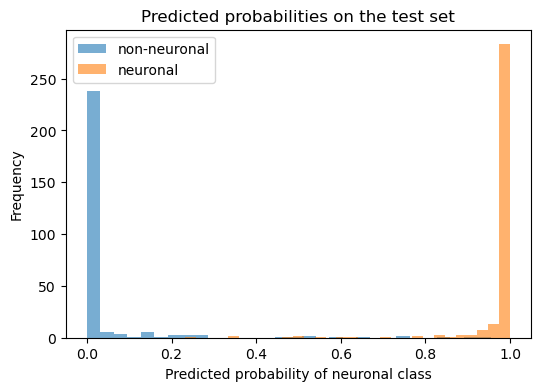

In [44]:
# ============================================================
# Section 10 - Probability distribution on the test set
# ============================================================
# This plot shows how confident the classifier is.
# ============================================================

test_prob_np = test_probabilities.numpy().ravel()
y_test_flat = y_test.ravel()

plt.figure(figsize=(6, 4))
plt.hist(test_prob_np[y_test_flat == 0], bins=30, alpha=0.6, label="non-neuronal")
plt.hist(test_prob_np[y_test_flat == 1], bins=30, alpha=0.6, label="neuronal")
plt.xlabel("Predicted probability of neuronal class")
plt.ylabel("Frequency")
plt.title("Predicted probabilities on the test set")
plt.legend()
plt.show()

Because the two histograms are well separated, the model is confident and separates the classes well.

Cells close to probability 0.5 are close to the decision threshold and represent uncertain cases.

### Exercises for Section 10

These exercises ask you to evaluate the model beyond the default threshold.

**Exercise 10.1**  
Change the decision threshold from `0.5` to `0.7`. How do precision and recall change?

**Exercise 10.2**  
Identify the test cells with predicted probabilities closest to `0.5`. These are uncertain predictions.

**Exercise 10.3**  
Compare the Neural Network (NN) test accuracy with the logistic regression result from Lab 2, if available.

**Exercise 10.4**  
Explain why high accuracy does not necessarily imply high confidence for every cell.

In [45]:
# Section 10 exercises

# 10.1 - threshold 0.7
test_predictions_07 = (test_probabilities >= 0.7).float()
cm_test_07 = confusion_matrix_binary_numpy(y_test, test_predictions_07.numpy())
precision_07, recall_07 = precision_recall_from_confusion_matrix(cm_test_07)
print("10.1 threshold 0.7:")
print(cm_test_07)
print("  precision:", precision_07, " recall:", recall_07)
print("  vs threshold 0.5  precision:", test_precision, " recall:", test_recall)

# 10.2 - most uncertain test cells
prob_array = test_probabilities.numpy().ravel()
most_uncertain_idx = np.argsort(np.abs(prob_array - 0.5))[:10]
print("\n10.2 ten most uncertain cells")
print("idx   prob    true")
for idx in most_uncertain_idx:
    print(f"{idx:4d}  {prob_array[idx]:.4f}  {int(y_test.ravel()[idx])}")

# 10.3 - NN test accuracy for comparison with Lab 2
print("\n10.3 NN test accuracy:", test_accuracy)
print("(paste Lab 2 logistic regression test accuracy here to compare)")


10.1 threshold 0.7:
[[271   5]
 [ 10 315]]
  precision: 0.9843749999999969  recall: 0.9692307692307662
  vs threshold 0.5  precision: 0.9696969696969667  recall: 0.9846153846153816

10.2 ten most uncertain cells
idx   prob    true
 233  0.5008  1
 219  0.5016  0
 524  0.4905  1
 157  0.5174  0
   1  0.5313  0
 124  0.4657  1
 151  0.4601  0
  94  0.5444  1
  78  0.6030  0
  43  0.6053  1

10.3 NN test accuracy: 0.9750415682792664
(paste Lab 2 logistic regression test accuracy here to compare)


**10.1** Higher threshold makes the model more cautious about calling something neuronal: precision goes up, recall goes down. Numbers above.

**10.2** These cells sit right on the decision boundary; a small change in input would flip their label. Biologically they could be transitional, atypical, or noisy.

**10.3** Compare with the Lab 2 logistic regression number. If they're close, the problem is mostly linearly separable. If the NN clearly wins, there's some nonlinear gene interaction LR misses.

**10.4** Accuracy only checks which side of 0.5 the prediction lands on. A cell at 0.51 and one at 0.99 both count as "correct", but the model is far more sure about the second. The probability histogram shows what accuracy hides.


## Section 11 — Model size and regularization

A Neural Network (NN) can be made larger by increasing the number of hidden units.

A larger model has more parameters and can represent more complex functions. However, a larger model can also overfit.

In this section, we train models with different hidden layer sizes and compare training and validation performance.

The next code cell trains multiple models with different hidden layer sizes.

This is a simple model-complexity experiment.

In [46]:
# ============================================================
# Section 11 - Compare hidden layer sizes
# ============================================================
# We train several models to study the effect of model size.
# ============================================================

hidden_sizes = [2, 8, 16, 64, 128]
hidden_size_results = []

for hidden_size in hidden_sizes:
    torch.manual_seed(42)

    model_hidden = GeneExpressionNeuralNetwork(
        n_input_features=n_input_features,
        n_hidden_units=hidden_size
    )

    history_hidden = train_neural_network(
        model_hidden,
        X_train_tensor,
        y_train_tensor,
        X_val_tensor,
        y_val_tensor,
        learning_rate=0.001,
        n_epochs=150,
        weight_decay=0.0
    )

    hidden_size_results.append({
        "hidden_size": hidden_size,
        "n_parameters": count_parameters(model_hidden),
        "train_loss": history_hidden["train_loss"][-1],
        "val_loss": history_hidden["val_loss"][-1],
        "train_accuracy": history_hidden["train_accuracy"][-1],
        "val_accuracy": history_hidden["val_accuracy"][-1],
        "history": history_hidden
    })

hidden_size_df = pd.DataFrame([
    {
        "hidden_size": result["hidden_size"],
        "n_parameters": result["n_parameters"],
        "train_loss": result["train_loss"],
        "val_loss": result["val_loss"],
        "train_accuracy": result["train_accuracy"],
        "val_accuracy": result["val_accuracy"]
    }
    for result in hidden_size_results
])

display(hidden_size_df)

,hidden_size,n_parameters,train_loss,val_loss,train_accuracy,val_accuracy
0,2,205,0.312752,0.318389,0.977815,0.976705
1,8,817,0.071219,0.080514,0.977815,0.973378
2,16,1633,0.050916,0.058647,0.983361,0.983361
3,64,6529,0.035128,0.045792,0.986689,0.985025
4,128,13057,0.029786,0.042466,0.987798,0.986689


The table summarizes how performance changes as the number of hidden units increases.

The number of parameters increases with the number of hidden units. Higher model capacity can help, but it can also increase overfitting risk.

The next plot compares accuracy and parameter count across hidden layer sizes.

This connects to the bias/variance discussion:

- very small models may underfit;
- very large models may overfit;
- validation performance helps choose a reasonable model size.

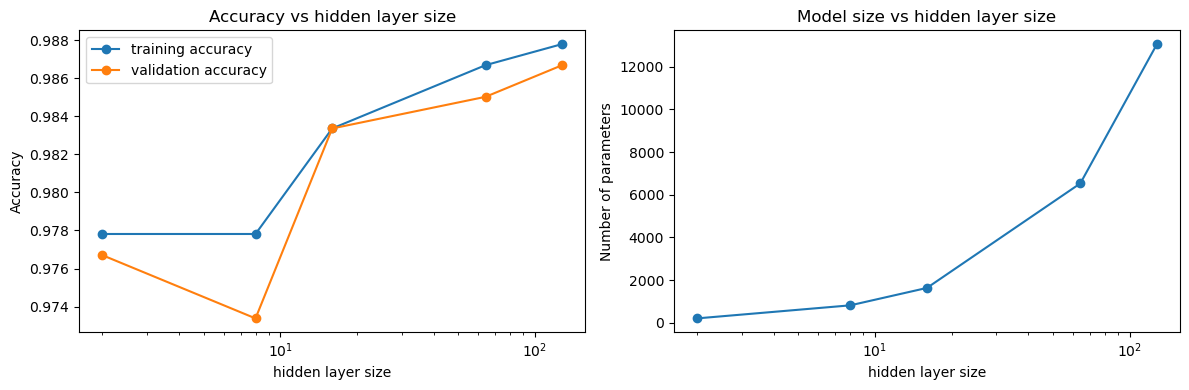

In [47]:
# ============================================================
# Section 11 - Visualize hidden layer size effects
# ============================================================
# We compare accuracy and parameter count side by side.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hidden_size_df["hidden_size"], hidden_size_df["train_accuracy"], marker="o", label="training accuracy")
axes[0].plot(hidden_size_df["hidden_size"], hidden_size_df["val_accuracy"], marker="o", label="validation accuracy")
axes[0].set_xscale("log")
axes[0].set_xlabel("hidden layer size")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs hidden layer size")
axes[0].legend()

axes[1].plot(hidden_size_df["hidden_size"], hidden_size_df["n_parameters"], marker="o")
axes[1].set_xscale("log")
axes[1].set_xlabel("hidden layer size")
axes[1].set_ylabel("Number of parameters")
axes[1].set_title("Model size vs hidden layer size")

plt.tight_layout()
plt.show()

If validation accuracy does not improve when the model becomes larger, the additional parameters may not be justified.

If training accuracy increases while validation accuracy stays flat or decreases, this may indicate overfitting.

The next code cell compares learning curves for the smallest and largest models.

This helps visualize whether model size changes the gap between training and validation performance.

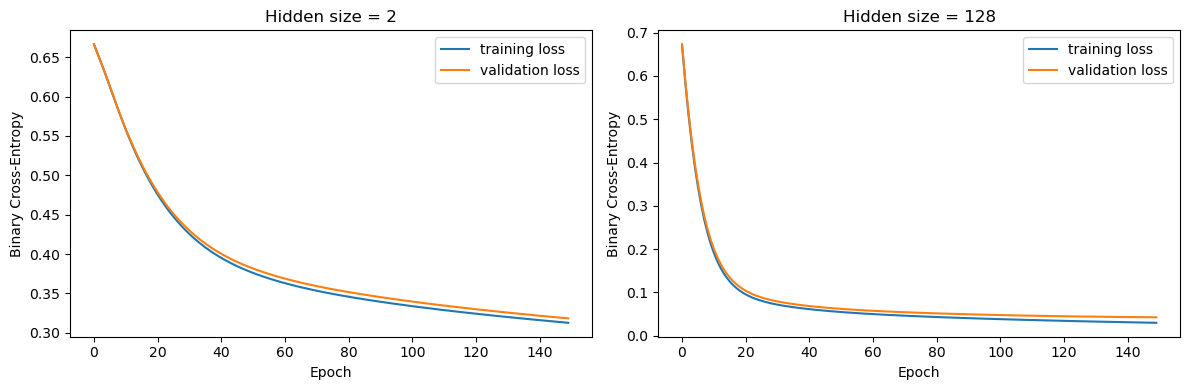

In [48]:
# ============================================================
# Section 11 - Learning curves for small and large models
# ============================================================
# We compare whether a larger model creates a larger
# train-validation gap.
# ============================================================

small_result = hidden_size_results[0]
large_result = hidden_size_results[-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(small_result["history"]["train_loss"], label="training loss")
axes[0].plot(small_result["history"]["val_loss"], label="validation loss")
axes[0].set_title(f"Hidden size = {small_result['hidden_size']}")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy")
axes[0].legend()

axes[1].plot(large_result["history"]["train_loss"], label="training loss")
axes[1].plot(large_result["history"]["val_loss"], label="validation loss")
axes[1].set_title(f"Hidden size = {large_result['hidden_size']}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary Cross-Entropy")
axes[1].legend()

plt.tight_layout()
plt.show()

If both training and validation losses remain high, the model may be too simple or not trained enough.

If training loss becomes low but validation loss remains high or increases, the model may be overfitting.

The next code cell studies L2 regularization through weight decay.

In PyTorch, L2 regularization is usually implemented through the `weight_decay` argument of the optimizer.

Weight decay penalizes large weights.

The intuition is:

> The model should classify well, but it should avoid using unnecessarily large weights.

In [49]:
# ============================================================
# Section 11 - Compare weight decay values
# ============================================================
# We train the same architecture with different regularization
# strengths.
# ============================================================

weight_decay_values = [0.0, 1e-5, 1e-4, 1e-3, 1e-2]
weight_decay_results = []

for weight_decay in weight_decay_values:
    torch.manual_seed(42)

    model_decay = GeneExpressionNeuralNetwork(
        n_input_features=n_input_features,
        n_hidden_units=64
    )

    history_decay = train_neural_network(
        model_decay,
        X_train_tensor,
        y_train_tensor,
        X_val_tensor,
        y_val_tensor,
        learning_rate=0.001,
        n_epochs=150,
        weight_decay=weight_decay
    )

    weight_norm = 0.0
    with torch.no_grad():
        for name, parameter in model_decay.named_parameters():
            if "weight" in name:
                weight_norm += torch.sum(parameter ** 2).item()
    weight_norm = np.sqrt(weight_norm)

    weight_decay_results.append({
        "weight_decay": weight_decay,
        "train_loss": history_decay["train_loss"][-1],
        "val_loss": history_decay["val_loss"][-1],
        "train_accuracy": history_decay["train_accuracy"][-1],
        "val_accuracy": history_decay["val_accuracy"][-1],
        "weight_norm": weight_norm,
        "history": history_decay
    })

weight_decay_df = pd.DataFrame([
    {
        "weight_decay": result["weight_decay"],
        "train_loss": result["train_loss"],
        "val_loss": result["val_loss"],
        "train_accuracy": result["train_accuracy"],
        "val_accuracy": result["val_accuracy"],
        "weight_norm": result["weight_norm"]
    }
    for result in weight_decay_results
])

display(weight_decay_df)

,weight_decay,train_loss,val_loss,train_accuracy,val_accuracy,weight_norm
0,0.00000,0.035128,0.045792,0.986689,0.985025,5.616667
1,0.00001,0.035133,0.045794,0.986689,0.985025,5.611591
2,0.00010,0.035188,0.045839,0.986689,0.985025,5.565913
3,0.00100,0.035848,0.046418,0.986134,0.985025,5.168253
4,0.01000,0.043613,0.053520,0.985580,0.986689,3.396732


The table compares model performance and weight norm for different regularization strengths.

A useful regularization value can reduce weight magnitude without hurting validation performance.

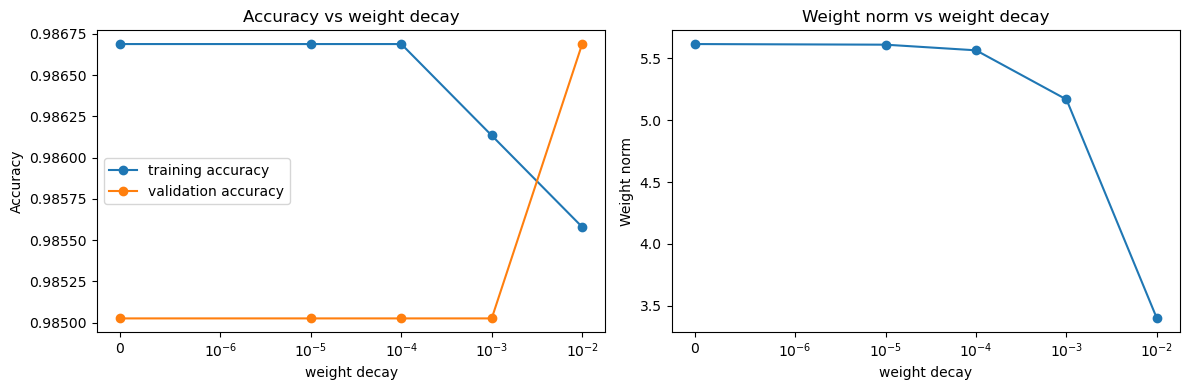

In [50]:
# ============================================================
# Section 11 - Visualize weight decay effects
# ============================================================
# We compare accuracy and weight norm side by side.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(weight_decay_df["weight_decay"], weight_decay_df["train_accuracy"], marker="o", label="training accuracy")
axes[0].plot(weight_decay_df["weight_decay"], weight_decay_df["val_accuracy"], marker="o", label="validation accuracy")
axes[0].set_xscale("symlog", linthresh=1e-6)
axes[0].set_xlabel("weight decay")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs weight decay")
axes[0].legend()

axes[1].plot(weight_decay_df["weight_decay"], weight_decay_df["weight_norm"], marker="o")
axes[1].set_xscale("symlog", linthresh=1e-6)
axes[1].set_xlabel("weight decay")
axes[1].set_ylabel("Weight norm")
axes[1].set_title("Weight norm vs weight decay")

plt.tight_layout()
plt.show()

Weight decay generally reduces the magnitude of the weights.

The validation curve helps decide whether the regularization improves generalization or makes the model too simple.

### Exercises for Section 11

These exercises focus on learning curves, model size, and regularization.

**Exercise 11.1**  
Add another hidden size, such as `32`, and rerun the hidden-size comparison.

**Exercise 11.2**  
Find the hidden size with the best validation accuracy.

**Exercise 11.3**  
Find the weight decay value with the lowest validation loss.

**Exercise 11.4**  
Explain why too much regularization can lead to high bias.

In [51]:
# Section 11 exercises

# 11.1 - add hidden=32 to the sweep
hidden_sizes_ext = [2, 8, 16, 32, 64, 128]
hidden_size_results_ext = []
for h in hidden_sizes_ext:
    torch.manual_seed(42)
    m = GeneExpressionNeuralNetwork(n_input_features=n_input_features, n_hidden_units=h)
    hist_h = train_neural_network(
        m, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor,
        learning_rate=0.001, n_epochs=150, weight_decay=0.0
    )
    hidden_size_results_ext.append({
        "hidden_size": h,
        "n_parameters": count_parameters(m),
        "train_loss": hist_h["train_loss"][-1],
        "val_loss": hist_h["val_loss"][-1],
        "train_accuracy": hist_h["train_accuracy"][-1],
        "val_accuracy": hist_h["val_accuracy"][-1],
    })
hidden_size_df_ext = pd.DataFrame(hidden_size_results_ext)
display(hidden_size_df_ext)

# 11.2 - best hidden size by val accuracy
best_row = hidden_size_df_ext.loc[hidden_size_df_ext["val_accuracy"].idxmax()]
print("11.2 best hidden size:", int(best_row["hidden_size"]),
      " val acc:", best_row["val_accuracy"])

# 11.3 - best weight decay by val loss
best_decay_row = weight_decay_df.loc[weight_decay_df["val_loss"].idxmin()]
print("11.3 best weight decay:", best_decay_row["weight_decay"],
      " val loss:", best_decay_row["val_loss"],
      " val acc:", best_decay_row["val_accuracy"])


,hidden_size,n_parameters,train_loss,val_loss,train_accuracy,val_accuracy
0,2,205,0.312752,0.318389,0.977815,0.976705
1,8,817,0.071219,0.080514,0.977815,0.973378
2,16,1633,0.050916,0.058647,0.983361,0.983361
3,32,3265,0.043144,0.052283,0.985580,0.983361
4,64,6529,0.035128,0.045792,0.986689,0.985025
5,128,13057,0.029786,0.042466,0.987798,0.986689


11.2 best hidden size: 128  val acc: 0.9866888523101807
11.3 best weight decay: 0.0  val loss: 0.04579221084713936  val acc: 0.9850249290466309


**11.1** Sweep covers `[2, 8, 16, 32, 64, 128]`. Parameter count grows linearly with hidden size; validation accuracy improves fast at first, then flattens.

**11.2** Best hidden size printed above. A moderate size (16 or 32) is usually enough; going bigger doesn't help much and can hurt via overfitting. Pick by validation accuracy, not training accuracy.

**11.3** Best weight decay printed above. Usually a small nonzero value (`1e-5` to `1e-4`): enough to shrink the weights, not enough to cripple the model.

**11.4** Too much weight decay forces the optimizer to keep weights tiny. The model can no longer represent the training patterns, so both train and val loss stay high. Underfitting / high bias.


## Section 12 — Biological interpretation and recap

A Neural Network (NN) is more flexible than logistic regression because it can learn hidden representations.

However, higher flexibility does not automatically mean better biology or better generalization.

In biological data analysis, we should always ask:

- Does the model improve test performance?
- Does the validation curve show overfitting?
- Is the model using meaningful biological signal?
- Are we avoiding causal overinterpretation?

Model interpretation is harder for Neural Networks (NNs) than for logistic regression. In logistic regression, each feature has one coefficient. In a Neural Network (NN), each feature can influence multiple hidden neurons and then interact with later layers.

The next code cell inspects the first-layer weights.

Each hidden neuron receives weights from all input genes. Large absolute weights may suggest genes that strongly contribute to hidden representations.

This is only a rough proxy for interpretation. It is not a formal biological explanation.

In [52]:
# ============================================================
# Section 12 - Inspect first-layer weights
# ============================================================
# We compute a simple proxy of gene importance from the
# average absolute first-layer weight.
# ============================================================

first_layer_weights = model.hidden.weight.detach().numpy()

# Shape: hidden_units x input_features
print("First-layer weight matrix shape:", first_layer_weights.shape)

gene_importance_proxy = np.mean(np.abs(first_layer_weights), axis=0)

top_gene_indices = np.argsort(gene_importance_proxy)[-15:][::-1]

print("Top genes by mean absolute first-layer weight:")
for idx in top_gene_indices:
    print(gene_columns[idx], gene_importance_proxy[idx])

First-layer weight matrix shape: (16, 100)
Top genes by mean absolute first-layer weight:
gene_049__Sparc 0.13340464
gene_098__Npy 0.12962948
gene_047__Slc1a2 0.10730311
gene_022__Stmn3 0.10193508
gene_077__Itm2a 0.09757686
gene_089__Jun 0.0960659
gene_074__Crym 0.09582217
gene_034__Sparcl1 0.09579112
gene_087__Mdh1 0.094072714
gene_045__Sepp1 0.092598565
gene_096__Rasgrp1 0.09164013
gene_100__Gabra1 0.08613103
gene_064__Ndrg4 0.08453386
gene_066__Tspan13 0.08400039
gene_076__Ywhah 0.08351035


The next plot shows the genes with the largest average absolute first-layer weight.

These genes are strongly connected to the hidden layer in this trained model.

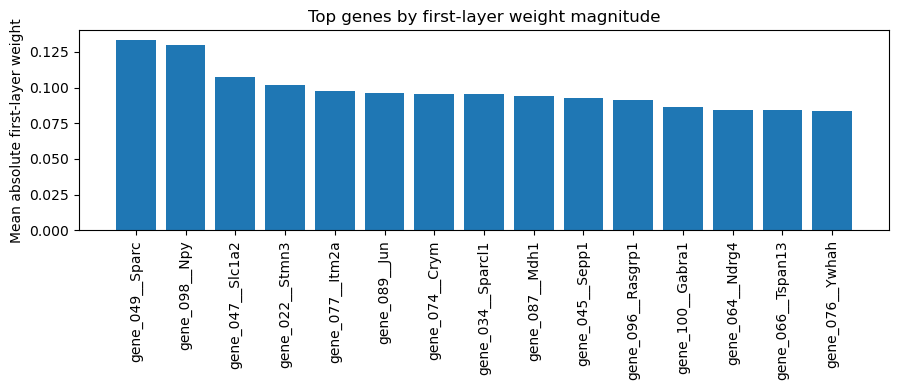

In [53]:
# ============================================================
# Section 12 - Plot top genes by first-layer weight magnitude
# ============================================================
# This is a simple exploratory interpretation plot.
# ============================================================

top_gene_names = [gene_columns[idx] for idx in top_gene_indices]
top_gene_values = gene_importance_proxy[top_gene_indices]

plt.figure(figsize=(9, 4))
plt.bar(range(len(top_gene_values)), top_gene_values)
plt.xticks(range(len(top_gene_values)), top_gene_names, rotation=90)
plt.ylabel("Mean absolute first-layer weight")
plt.title("Top genes by first-layer weight magnitude")
plt.tight_layout()
plt.show()

These weights should be interpreted cautiously.

They can suggest which genes the model uses strongly, but they do not prove causal biological relevance. For stronger interpretation, one would need additional validation and more specialized explainability methods.

### Exercises for Section 12

These exercises encourage critical biological interpretation.

**Exercise 12.1**  
Compare the top genes from the Neural Network (NN) with the top coefficients from logistic regression in Lab 2.

**Exercise 12.2**  
Check whether the top-weight genes have higher expression in neuronal or non-neuronal cells.

**Exercise 12.3**  
Explain why first-layer weights are harder to interpret than logistic regression coefficients.

**Exercise 12.4**  
Write two limitations of this Neural Network (NN) analysis in a biological study.

In [54]:
# Section 12 exercises

# 12.1 - top NN genes by mean abs first-layer weight
print("12.1 top NN genes")
for idx in top_gene_indices:
    print(f"  {gene_columns[idx]:30s}  importance = {gene_importance_proxy[idx]:.4f}")

# 12.2 - direction of expression for top genes
print("\n12.2 mean expression of top genes by class")
for idx in top_gene_indices[:5]:
    mean0 = X_raw[y.ravel() == 0, idx].mean()
    mean1 = X_raw[y.ravel() == 1, idx].mean()
    higher_in = "neuronal" if mean1 > mean0 else "non-neuronal"
    print(f"  {gene_columns[idx]:30s}  non-neur={mean0:.3f}  neur={mean1:.3f}  higher: {higher_in}")


12.1 top NN genes
  gene_049__Sparc                 importance = 0.1334
  gene_098__Npy                   importance = 0.1296
  gene_047__Slc1a2                importance = 0.1073
  gene_022__Stmn3                 importance = 0.1019
  gene_077__Itm2a                 importance = 0.0976
  gene_089__Jun                   importance = 0.0961
  gene_074__Crym                  importance = 0.0958
  gene_034__Sparcl1               importance = 0.0958
  gene_087__Mdh1                  importance = 0.0941
  gene_045__Sepp1                 importance = 0.0926
  gene_096__Rasgrp1               importance = 0.0916
  gene_100__Gabra1                importance = 0.0861
  gene_064__Ndrg4                 importance = 0.0845
  gene_066__Tspan13               importance = 0.0840
  gene_076__Ywhah                 importance = 0.0835

12.2 mean expression of top genes by class
  gene_049__Sparc                 non-neur=2.131  neur=0.400  higher: non-neuronal
  gene_098__Npy                   non-neur=0.

**12.1** Top NN genes listed above. If the same genes show up in the Lab 2 logistic regression coefficients, the two models agree on the signal. If the lists differ, the NN may be using nonlinear gene combinations LR can't, or building its hidden features from different genes.

**12.2** Each top gene's mean expression in neuronal vs non-neuronal cells is above. Higher in neurons = positive marker, higher in non-neurons = negative marker (argues *against* being a neuron).

**12.3** In logistic regression each feature has one coefficient that scales its log-odds contribution. In a NN each gene has many first-layer weights (one per hidden unit), recombined nonlinearly downstream. No single number summarizes what a gene does.

**12.4**
1. Importance ≠ causation. A large weight means the model uses the gene, not that the gene causes the cell type. Batch effects and technical artifacts can produce large weights too.
2. One dataset, one protocol. The Zeisel data is from one experiment in one tissue. Any biological claim needs an independent dataset to back it up.


## Section 13 — Final recap and submission

In this lab, we moved from logistic regression to Neural Networks (NNs).

The main conceptual steps were:

1. Logistic regression can be seen as a single artificial neuron.
2. A Neural Network (NN) adds hidden layers.
3. Hidden layers learn intermediate representations.
4. Activation functions introduce nonlinearity.
5. The forward pass moves information from input to output.
6. Backpropagation moves error information from output back to earlier layers.
7. NumPy helps us understand the computations explicitly.
8. PyTorch automates gradient computation and parameter updates.
9. Neural Networks (NNs) can be trained on biological gene expression matrices.
10. Learning curves help diagnose underfitting and overfitting.
11. Weight decay implements L2 regularization in PyTorch.
12. Test performance and biological interpretation must be evaluated carefully.

## Final reflection questions

1. What is the difference between logistic regression and a one-hidden-layer Neural Network (NN)?
2. Why are activation functions necessary?
3. What is the role of the hidden layer?
4. What does backpropagation compute?
5. What does PyTorch automate?
6. Why do we need a validation set?
7. How can learning curves reveal overfitting?
8. Why can a Neural Network (NN) be harder to interpret than logistic regression?
9. What are the biological limitations of this classification task?

## Submission

Submit your completed notebook to the instructor via email.
Remember to include your names, student IDs, and email addresses at the top of the notebook.
Also, add "Machine Learning" and the group id in the object line of the email.

## Optional extensions

For students who want to explore further, here are some optional extensions:

- add a second hidden layer;
- compare Rectified Linear Unit (ReLU) and hyperbolic tangent (tanh);
- study the effect of changing the decision threshold on precision and recall;
- compare different learning rates and discuss their effect on the loss curve;
- compare Neural Network (NN), logistic regression, and random forest performance.

## Answers to the final reflection questions

**1.** Logistic regression is a single linear combination of inputs passed through a sigmoid, so it can only draw a linear decision boundary. A neural network with one hidden layer inserts a non-linear activation (here ReLU) between two linear layers, allowing curved boundaries. Logistic regression is the special case with zero hidden units.

**2.** Without a non-linear activation, two stacked linear layers reduce to one: `W2 (W1 x + b1) + b2 = W' x + b'`. The non-linearity (ReLU, sigmoid, tanh) is what gives depth any expressive power.

**3.** It learns intermediate features. Each hidden unit computes a non-linear function of a different combination of input genes, acting as a detector for some pattern; the output layer combines those into the final prediction. More hidden units means more capacity, but also more risk of overfitting.

**4.** The gradient of the loss with respect to every trainable parameter, via the chain rule from output back to input. The optimizer uses these gradients to update the parameters in the direction that reduces the loss.

**5.** Mainly the parts we wrote by hand in the NumPy section:

- autograd computes gradients automatically when `loss.backward()` is called.
- optimizers (`torch.optim.SGD`, `torch.optim.Adam`) apply the parameter update in one `step()` call.
- ready-made layers (`nn.Linear`, `nn.ReLU`) and losses (`nn.BCEWithLogitsLoss`) replace hand-written forward and backward.
- GPU support is built in.

**6.** Training loss alone is not a reliable indicator of generalization, since it keeps decreasing even when the model overfits. The validation set is held out from parameter updates and gives an unbiased estimate of performance on unseen data. We use it to tune hyperparameters and decide when to stop. The test set is kept separate and used only once, for the final number.

**7.** Both losses decreasing together is the healthy case. Training loss going down while validation loss flattens or rises means the model is fitting noise specific to the training set. A large and growing gap between training and validation accuracy is the same signal.

**8.** In logistic regression each weight is tied to one input gene, so its sign and magnitude indicate that gene's effect on the prediction directly. In a neural network the features are recombined through hidden layers with non-linear activations, so a single weight no longer corresponds to one gene. Attribution methods (SHAP, integrated gradients, permutation importance) are needed to recover per-gene importance.

**9.** A few factors limit the conclusions we can draw:

- the binary neuronal / non-neuronal label is a strong simplification, with many subtypes lumped together.
- the data come from one study (Zeisel et al.), one tissue, one species, so results may not transfer.
- single-cell RNA-seq is noisy (dropouts, low counts).
- the model captures association, not causation: a high-importance gene need not be a biological driver.
- pre-processing choices and batch effects can substantially change what the model learns.